# Hot City, Heated Calls: EDA
## Understanding Extreme Heat and Quality of Life Using NYC's 311 and SHAP

**Goal:** Estimate how heat exposure changes urban livability—proxied by the rate of quality-of-life (QoL)-related 311 complaints per capita—controlling for environmental, socioeconomic, and urban morphology conditions across New York City tracts.

**Research Question:** How does heat exposure influence urban livability—as reflected in the proportion of QoL-related 311 service requests—across census tracts in New York City after accounting for environmental, socioeconomic, and urban morphology conditions?

## 1. Setup and Data Loading

In [31]:
# Import necessary libraries for data analysis and visualization.
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
import warnings

# Spatial analysis libraries.
from libpysal.weights import KNN, Queen
from esda.moran import Moran, Moran_Local
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Suppress warnings for cleaner output.
warnings.filterwarnings("ignore")

# Set visualization parameters.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Set random seed for reproducibility.
np.random.seed(42)

# Font paths.
aleo_path = "data/fonts/Aleo/Aleo-VariableFont_wght.ttf"

# Register fonts.
fm.fontManager.addfont(aleo_path)

# Create FontProperties objects.
font_aleo = fm.FontProperties(fname = aleo_path)

# Global fonts.
plt.rcParams["font.family"] = font_aleo.get_name()
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "normal"
plt.rcParams["font.size"] = 12

In [32]:
# Load model data and spatial boundaries.
data_path = "data/model/Final_Data_Model.csv"
boundaries_path = "data/nyc_city_boundary_land_only/nyc_city_boundary_land_only.shp"
tracts_path = "data/nyc_tracts_2020/nyc_tracts_2020.shp"

# Read CSV data.
df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"Total census tracts: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")

# Read spatial data.
boundaries = gpd.read_file(boundaries_path)
tracts = gpd.read_file(tracts_path)
tracts = tracts.rename(columns = {"geoid" : "GEOID"})

boundaries = boundaries.to_crs(tracts.crs)

print(f"\nTracts shapefile loaded: {tracts.shape[0]} geometries")
print(f"CRS: {tracts.crs}")

Dataset shape: (2225, 20)
Total census tracts: 2225
Total features: 20

Tracts shapefile loaded: 2325 geometries
CRS: GEOGCS["WGS84(DD)",DATUM["WGS84",SPHEROID["WGS84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [33]:
# Merge data with spatial boundaries for mapping.
# Convert GEOID to string for consistent merging.
df["GEOID"] = df["GEOID"].astype(str)
tracts["GEOID"] = tracts["GEOID"].astype(str)

# Perform left join to keep all spatial geometries.
gdf = tracts.merge(df, on = "GEOID", how = "left")
print(f"\nMerged GeoDataFrame shape: {gdf.shape}")
print(f"Tracts with data: {gdf["TOTAL_POP_x"].notna().sum()}")
print(f"Tracts without data: {gdf["TOTAL_POP_x"].isna().sum()}")


Merged GeoDataFrame shape: (2325, 33)
Tracts with data: 2225
Tracts without data: 100


## 2. Data Overview and Summary Statistics

In [34]:
# Display basic dataset information.
print("DATASET INFORMATION")

print(f"\nTotal Observations: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"\nColumn Names:")

# Number them.
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

DATASET INFORMATION

Total Observations: 2225
Total Features: 20

Column Names:
 1. GEOID
 2. TOTAL_POP_x
 3. heatweek_avg_qol_calls
 4. normalweek_avg_qol_calls
 5. heatweek_calls_per_1k
 6. normalweek_calls_per_1k
 7. PCT_BACHELORS_PLUS
 8. PCT_RENTERS
 9. PCT_LIMITED_ENGLISH
10. MEDIAN_INCOME
11. POVERTY_RATE
12. PCT_NON_WHITE
13. PCT_TREE_CANOPY
14. PCT_IMPERVIOUS
15. WCR
16. NDVI
17. BD
18. AH
19. POI_500M_DENSITY
20. KNN_SUBWAY_dist_mean


In [35]:
# Examine data types and missing values.
print("DATA TYPES AND MISSING VALUES\n")

info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.count(),
    "Null Count": df.isnull().sum(),
    "Null Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

print(info_df.to_string())

# Highlight columns with missing values.
missing_cols = info_df[info_df["Null Count"] > 0]

if len(missing_cols) > 0:
    print("\nColumns with missing values:")
    print(missing_cols[["Null Count", "Null Percentage"]].to_string())
else:
    print("\nNo missing values.")

DATA TYPES AND MISSING VALUES

                         Data Type  Non-Null Count  Null Count  Null Percentage
GEOID                       object            2225           0              0.0
TOTAL_POP_x                float64            2225           0              0.0
heatweek_avg_qol_calls     float64            2225           0              0.0
normalweek_avg_qol_calls   float64            2225           0              0.0
heatweek_calls_per_1k      float64            2225           0              0.0
normalweek_calls_per_1k    float64            2225           0              0.0
PCT_BACHELORS_PLUS         float64            2225           0              0.0
PCT_RENTERS                float64            2225           0              0.0
PCT_LIMITED_ENGLISH        float64            2225           0              0.0
MEDIAN_INCOME                int64            2225           0              0.0
POVERTY_RATE               float64            2225           0              0.0
PCT_NON_W

In [36]:
# Define predictor categories based on project description.
# Socioeconomic and demographic predictors.
acs_predictors = [
    "PCT_BACHELORS_PLUS",
    "PCT_RENTERS",
    "PCT_LIMITED_ENGLISH",
    "MEDIAN_INCOME",
    "POVERTY_RATE",
    "PCT_NON_WHITE"
]

# Environmental predictors.
env_predictors = [
    "PCT_TREE_CANOPY",
    "PCT_IMPERVIOUS",
    "WCR",
    "NDVI"
]

# Urban form predictors.
urban_predictors = [
    "BD",
    "AH",
    "POI_500M_DENSITY",
    "KNN_SUBWAY_dist_mean"
]

# Combined predictor set with all features.
all_predictors = env_predictors + acs_predictors + urban_predictors

# Target variables.
targets = ["heatweek_calls_per_1k", "normalweek_calls_per_1k"]

# Additional call count variables.
call_vars = ["heatweek_avg_qol_calls", "normalweek_avg_qol_calls"]

print("PREDICTOR CATEGORIES\n")

print(f"Environmental Predictors: {len(env_predictors)}")
print(f"Socioeconomic Predictors: {len(acs_predictors)}")
print(f"Urban Form Predictors: {len(urban_predictors)}")
print(f"Total Predictors: {len(all_predictors)}")
print(f"Target Variables: {len(targets)}")

PREDICTOR CATEGORIES

Environmental Predictors: 4
Socioeconomic Predictors: 6
Urban Form Predictors: 4
Total Predictors: 14
Target Variables: 2


In [37]:
# Summary stats for all numeric variables.
print("SUMMARY STATS")

summary_all = df.describe().T
summary_all["skew"] = df.skew(numeric_only = True)
summary_all["kurtosis"] = df.kurtosis(numeric_only = True)

print(summary_all.to_string())

SUMMARY STATS
                           count          mean           std           min           25%           50%            75%            max       skew    kurtosis
TOTAL_POP_x               2225.0  3.872135e+03  1.949897e+03  5.700000e+01   2469.000000   3551.000000    4939.000000   15945.000000   1.142894    2.371892
heatweek_avg_qol_calls    2225.0  5.506854e+00  8.709629e+00  0.000000e+00      2.000000      3.800000       6.600000     180.200000  10.836368  165.185451
normalweek_avg_qol_calls  2225.0  5.985753e+00  8.759979e+00  0.000000e+00      2.428571      4.285714       7.142857     196.714286  11.084346  180.326227
heatweek_calls_per_1k     2225.0  1.793526e+00  4.224669e+00  0.000000e+00      0.577901      1.061477       1.890281     133.333333  17.769107  464.692226
normalweek_calls_per_1k   2225.0  1.892240e+00  3.661588e+00  0.000000e+00      0.729677      1.190285       1.998380      97.744361  13.517720  271.702411
PCT_BACHELORS_PLUS        2225.0  3.812916e-01  2.

In [38]:
# Summary stats by predictor category.
print("SUMMARY STATS - ENVIRONMENTAL PREDICTORS\n")
print(df[env_predictors].describe().T.to_string())

print("\nSUMMARY STATS - SOCIOECONOMIC PREDICTORS\n")
print(df[acs_predictors].describe().T.to_string())

print("\nSUMMARY STATS - URBAN FORM PREDICTORS\n")
print(df[urban_predictors].describe().T.to_string())

print("\nSUMMARY STATS - TARGET VARIABLES\n")
print(df[targets + call_vars].describe().T.to_string())

SUMMARY STATS - ENVIRONMENTAL PREDICTORS

                  count      mean       std       min       25%       50%       75%        max
PCT_TREE_CANOPY  2225.0  5.647950  7.548684  0.000000  0.844311  2.670270  8.112802  63.857995
PCT_IMPERVIOUS   2225.0  1.222685  0.181811  0.653538  1.086207  1.181818  1.316038   2.000000
WCR              2225.0  0.005148  0.029364  0.000000  0.000000  0.000000  0.000000   0.498365
NDVI             2225.0  0.061671  0.028007  0.006806  0.041246  0.056417  0.076770   0.192557

SUMMARY STATS - SOCIOECONOMIC PREDICTORS

                      count          mean           std          min           25%           50%            75%            max
PCT_BACHELORS_PLUS   2225.0  3.812916e-01  2.130461e-01          0.0      0.221082      0.335332       0.495343       0.943896
PCT_RENTERS          2225.0  6.257074e-01  2.543447e-01          0.0      0.441509      0.656321       0.834302       1.000000
PCT_LIMITED_ENGLISH  2225.0  6.222821e-03  1.202145e-02    

## 3. Univariate Analysis

### 3.1 Target Variables Distribution

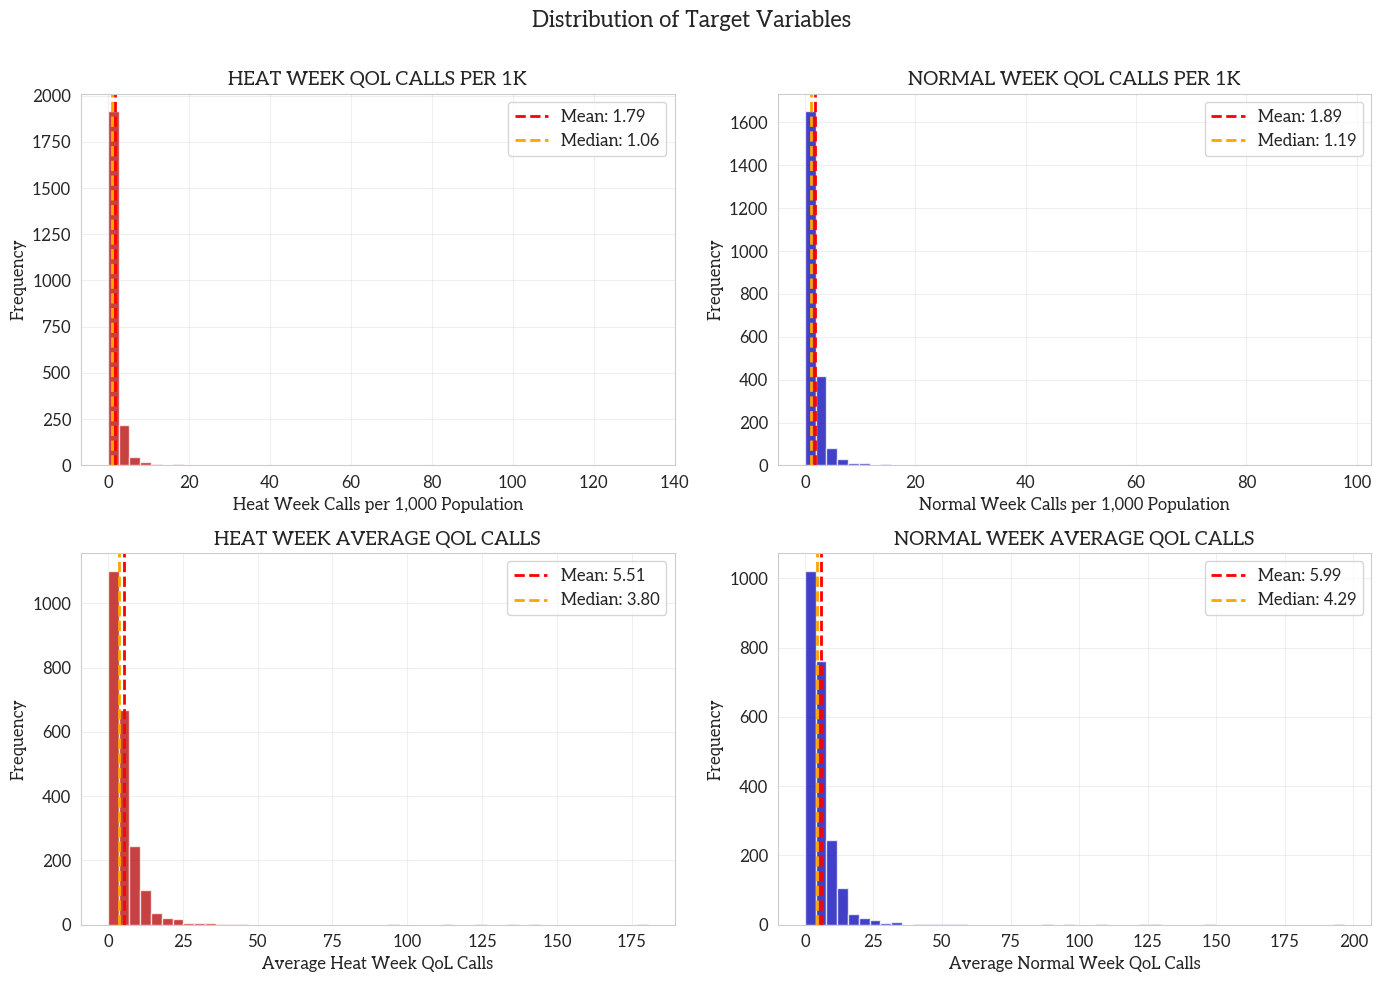

In [90]:
# Distribution viz of target variables with histograms and KDE.
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle("Distribution of Target Variables\n", fontsize = 16, fontweight = "bold")

# Heat week calls per 1k.
axes[0, 0].hist(df["heatweek_calls_per_1k"], bins = 50,
                edgecolor = "white", alpha = 0.75, color = "#b60101")

axes[0, 0].axvline(df["heatweek_calls_per_1k"].mean(), color = "red", linestyle = "--", linewidth = 2,
                   label = f"Mean: {df['heatweek_calls_per_1k'].mean():.2f}")

axes[0, 0].axvline(df["heatweek_calls_per_1k"].median(), color = "orange", linestyle = "--", linewidth = 2,
                   label = f"Median: {df['heatweek_calls_per_1k'].median():.2f}")

axes[0, 0].set_xlabel("Heat Week Calls per 1,000 Population")

axes[0, 0].set_ylabel("Frequency")

axes[0, 0].set_title("HEAT WEEK QOL CALLS PER 1K")

axes[0, 0].legend()

axes[0, 0].grid(alpha = 0.3)

# Normal week calls per 1k.
axes[0, 1].hist(df["normalweek_calls_per_1k"], bins = 50,
                edgecolor = "white", alpha = 0.75, color = "#0101B6")

axes[0, 1].axvline(df["normalweek_calls_per_1k"].mean(), color = "red", linestyle = "--", linewidth = 2,
                   label = f"Mean: {df['normalweek_calls_per_1k'].mean():.2f}")

axes[0, 1].axvline(df["normalweek_calls_per_1k"].median(), color = "orange", linestyle = "--", linewidth = 2,
                   label = f"Median: {df['normalweek_calls_per_1k'].median():.2f}")

axes[0, 1].set_xlabel("Normal Week Calls per 1,000 Population")

axes[0, 1].set_ylabel("Frequency")

axes[0, 1].set_title("NORMAL WEEK QOL CALLS PER 1K")

axes[0, 1].legend()

axes[0, 1].grid(alpha = 0.3)

# Average QoL calls during heat weeks.
axes[1, 0].hist(df["heatweek_avg_qol_calls"], bins = 50,
                edgecolor = "white", alpha = 0.75, color = "#b60101")

axes[1, 0].axvline(df["heatweek_avg_qol_calls"].mean(), color = "red", linestyle = "--", linewidth = 2,
                   label = f"Mean: {df['heatweek_avg_qol_calls'].mean():.2f}")

axes[1, 0].axvline(df["heatweek_avg_qol_calls"].median(), color = "orange", linestyle = "--", linewidth = 2,
                   label = f"Median: {df['heatweek_avg_qol_calls'].median():.2f}")

axes[1, 0].set_xlabel("Average Heat Week QoL Calls")

axes[1, 0].set_ylabel("Frequency")

axes[1, 0].set_title("HEAT WEEK AVERAGE QOL CALLS")

axes[1, 0].legend()

axes[1, 0].grid(alpha = 0.3)

# Average QoL calls during normal weeks.
axes[1, 1].hist(df["normalweek_avg_qol_calls"], bins = 50,
                edgecolor = "white", alpha = 0.75, color = "#0101B6")

axes[1, 1].axvline(df["normalweek_avg_qol_calls"].mean(), color = "red", linestyle = "--", linewidth = 2,
                   label = f"Mean: {df['normalweek_avg_qol_calls'].mean():.2f}")

axes[1, 1].axvline(df["normalweek_avg_qol_calls"].median(), color = "orange", linestyle = "--", linewidth = 2,
                   label = f"Median: {df['normalweek_avg_qol_calls'].median():.2f}")

axes[1, 1].set_xlabel("Average Normal Week QoL Calls")

axes[1, 1].set_ylabel("Frequency")

axes[1, 1].set_title("NORMAL WEEK AVERAGE QOL CALLS")

axes[1, 1].legend()

axes[1, 1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

Mean difference (heat - normal): -0.0987 calls per 1k

Median difference: -0.1145 calls per 1k

Tracts with higher calls during heat weeks: 852 (38.3%)

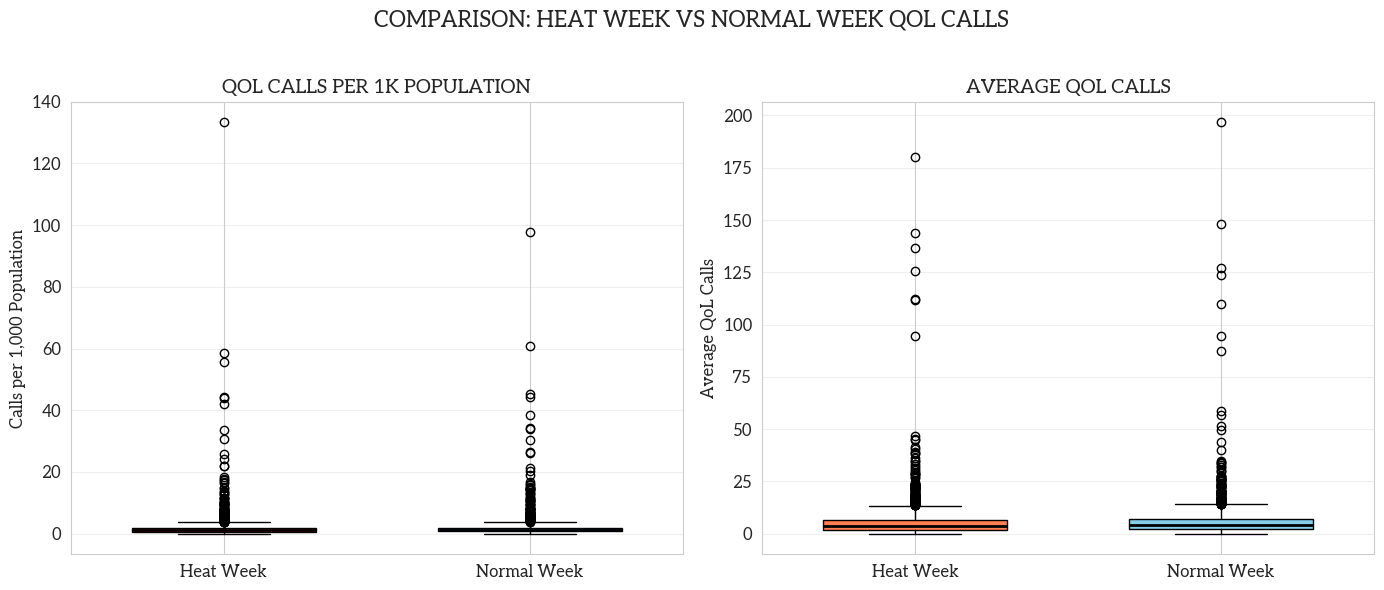

In [93]:
# Boxplot comparison of heat vs normal week calls.
fig, axes = plt.subplots(1, 2, figsize = (14, 6))
fig.suptitle("COMPARISON: HEAT WEEK VS NORMAL WEEK QOL CALLS\n", fontsize = 16, fontweight = "bold")

# Calls per 1k comparison.
box_data_1 = [df["heatweek_calls_per_1k"].dropna(), df["normalweek_calls_per_1k"].dropna()]

bp1 = axes[0].boxplot(box_data_1, labels = ["Heat Week", "Normal Week"], patch_artist = True, widths = 0.6)

bp1["boxes"][0].set_facecolor("orangered")

bp1["boxes"][1].set_facecolor("steelblue")

for median in bp1["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

axes[0].set_ylabel("Calls per 1,000 Population")

axes[0].set_title("QOL CALLS PER 1K POPULATION")

axes[0].grid(alpha = 0.3, axis = "y")

# Average calls comparison.
box_data_2 = [df["heatweek_avg_qol_calls"].dropna(), df["normalweek_avg_qol_calls"].dropna()]

bp2 = axes[1].boxplot(box_data_2, labels = ["Heat Week", "Normal Week"], patch_artist = True, widths = 0.6)

bp2["boxes"][0].set_facecolor("coral")

bp2["boxes"][1].set_facecolor("skyblue")

for median in bp2["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

axes[1].set_ylabel("Average QoL Calls")

axes[1].set_title("AVERAGE QOL CALLS")

axes[1].grid(alpha = 0.3, axis = "y")

plt.tight_layout()
plt.show()

### 3.2 Environmental Predictors

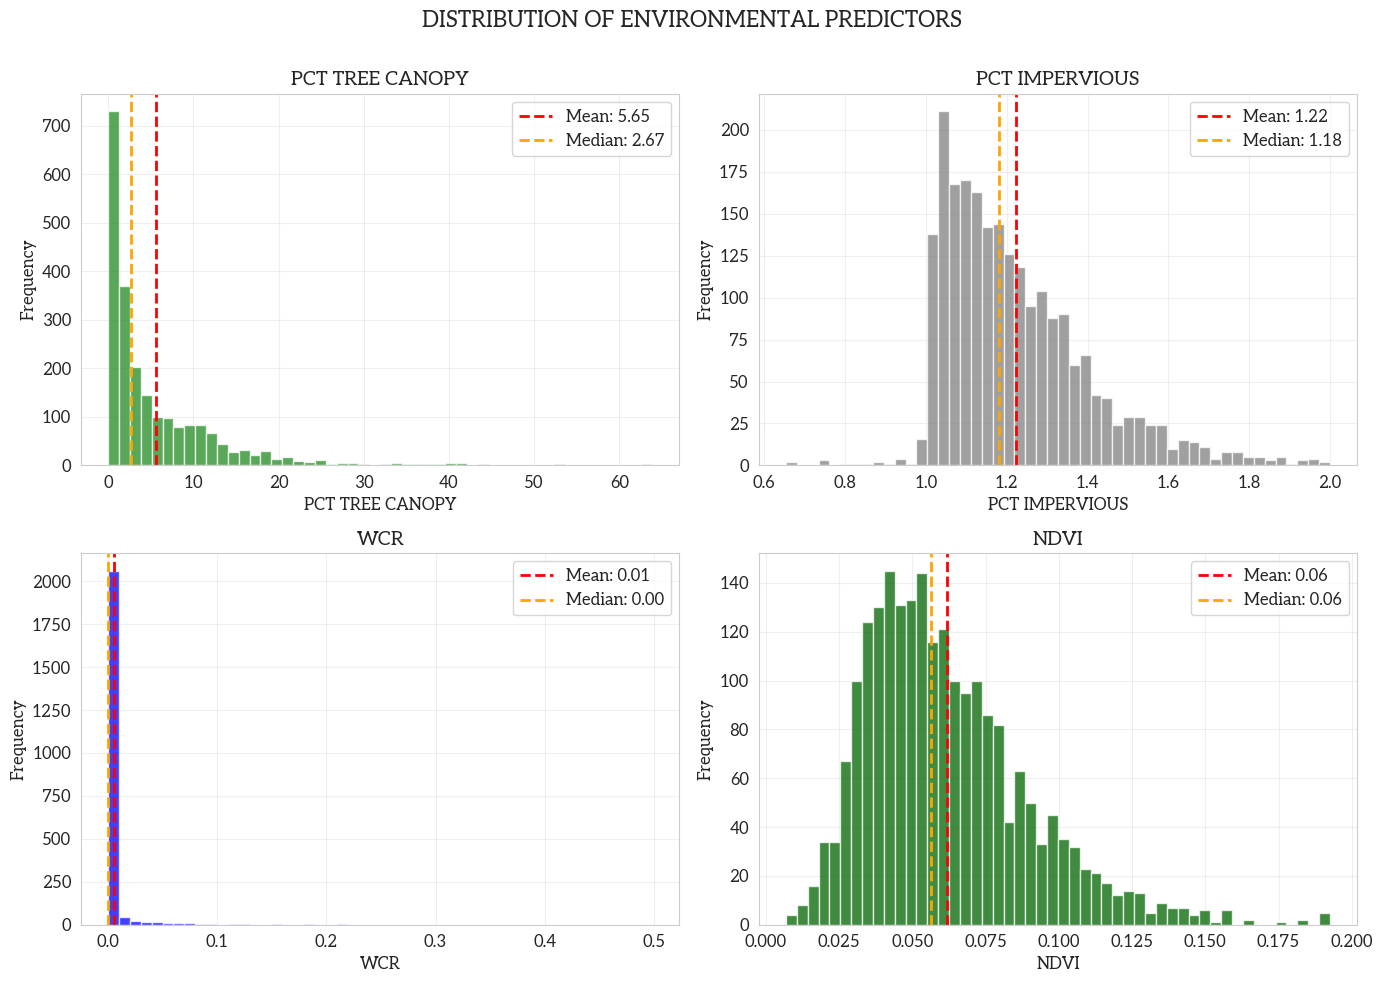

In [94]:
# Distribution viz of environmental predictors.
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle("DISTRIBUTION OF ENVIRONMENTAL PREDICTORS\n", fontsize = 16, fontweight = "bold")

colors = ["forestgreen", "gray", "blue", "darkgreen"]

for idx, (var, color) in enumerate(zip(env_predictors, colors)):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].hist(df[var].dropna(), bins = 50,
                        edgecolor = "white", alpha = 0.75, color = color)
    
    axes[row, col].axvline(df[var].mean(), color = "red", linestyle = "--", linewidth = 2,
                           label = f"Mean: {df[var].mean():.2f}")
    
    axes[row, col].axvline(df[var].median(), color = "orange", linestyle = "--", linewidth = 2,
                           label = f"Median: {df[var].median():.2f}")
    
    axes[row, col].set_xlabel(var.replace("_", " ").upper())
    
    axes[row, col].set_ylabel("Frequency")

    axes[row, col].set_title(var.replace("_", " ").upper())

    axes[row, col].legend()

    axes[row, col].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### 3.3 Socioeconomic Predictors

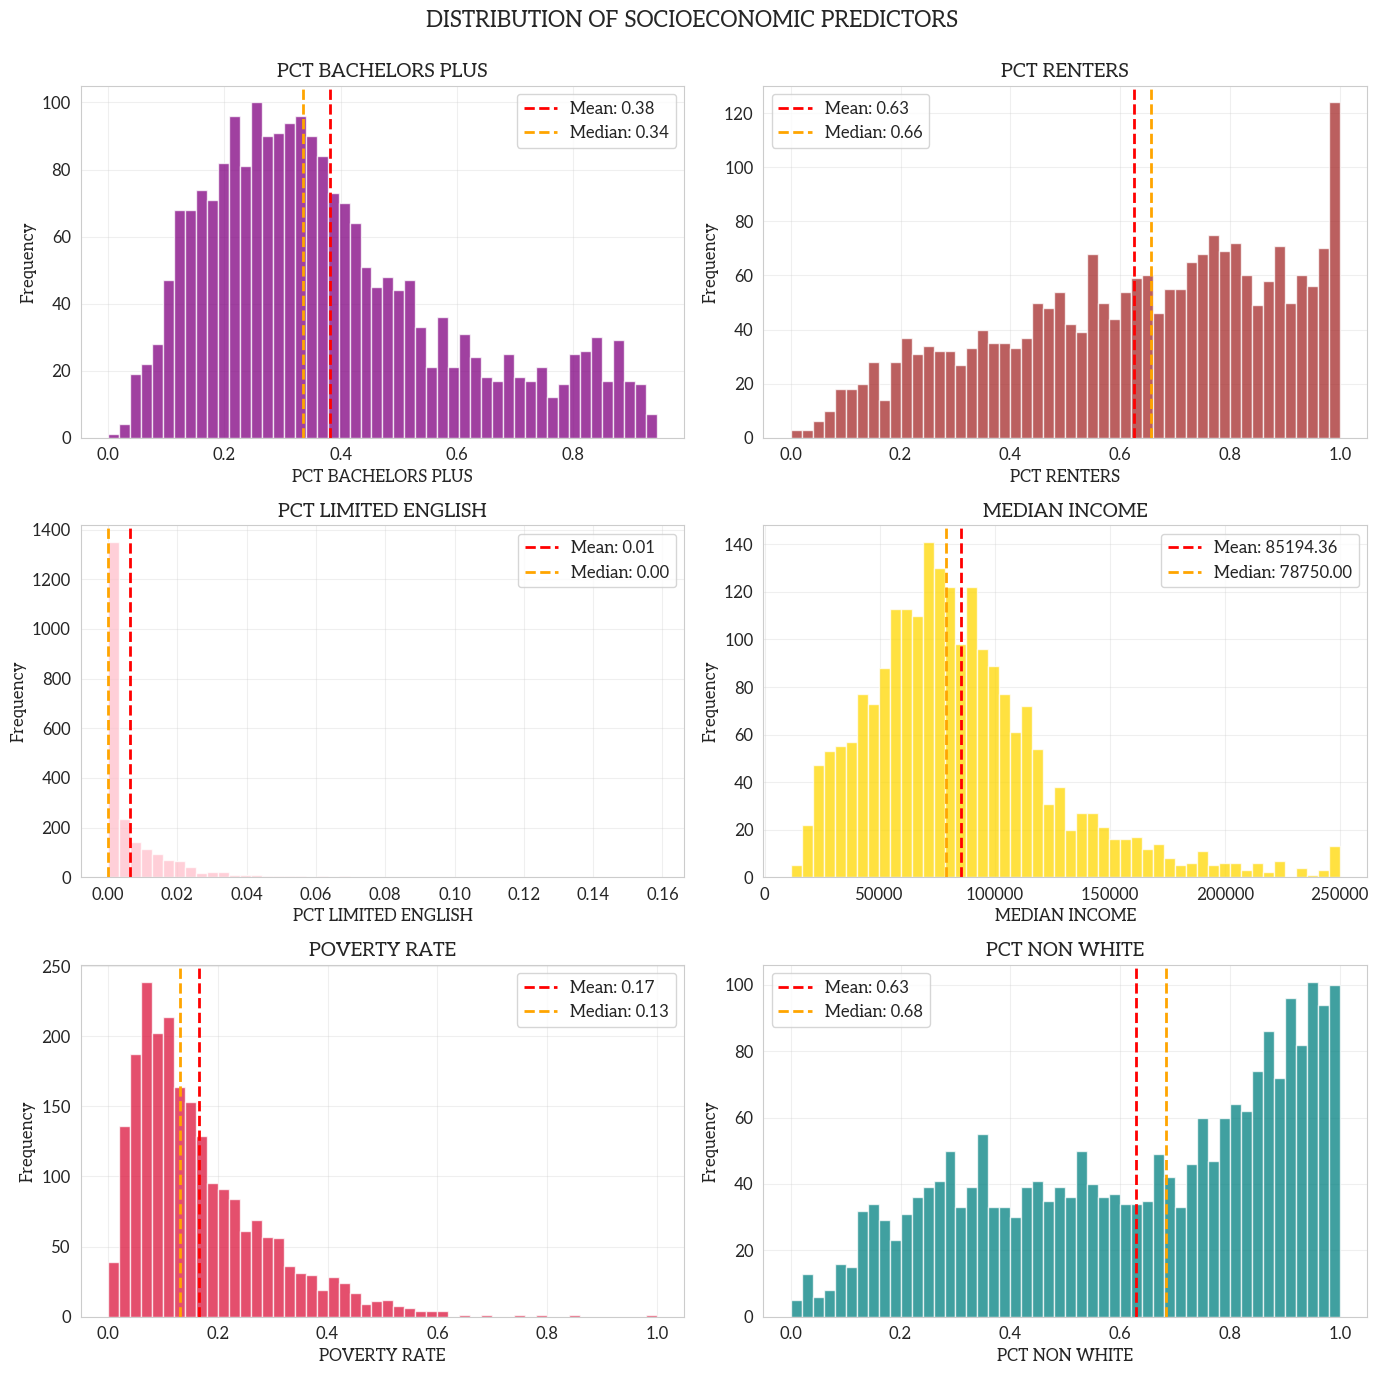

In [95]:
# Distribution viz of socioeconomic predictors.
fig, axes = plt.subplots(3, 2, figsize = (14, 14))
fig.suptitle("DISTRIBUTION OF SOCIOECONOMIC PREDICTORS\n", fontsize = 16, fontweight = "bold")

colors = ["purple", "brown", "pink", "gold", "crimson", "teal"]

for idx, (var, color) in enumerate(zip(acs_predictors, colors)):
    row = idx // 2
    col = idx % 2
    
    # Handle special case for MEDIAN_INCOME which may have placeholder values.
    data = df[var].copy()
    
    if var == "MEDIAN_INCOME":
        data = data[data > 0]  # Filter out negative placeholder values.
    
    axes[row, col].hist(data.dropna(), bins = 50,
                        edgecolor = "white", alpha = 0.75, color = color)
    
    axes[row, col].axvline(data.mean(), color = "red", linestyle = "--", linewidth = 2,
                           label = f"Mean: {data.mean():.2f}")
    
    axes[row, col].axvline(data.median(), color = "orange", linestyle = "--", linewidth = 2,
                           label = f"Median: {data.median():.2f}")
    
    axes[row, col].set_xlabel(var.replace("_", " ").upper())

    axes[row, col].set_ylabel("Frequency")

    axes[row, col].set_title(var.replace("_", " ").upper())

    axes[row, col].legend()
    
    axes[row, col].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### 3.4 Urban Form Predictors

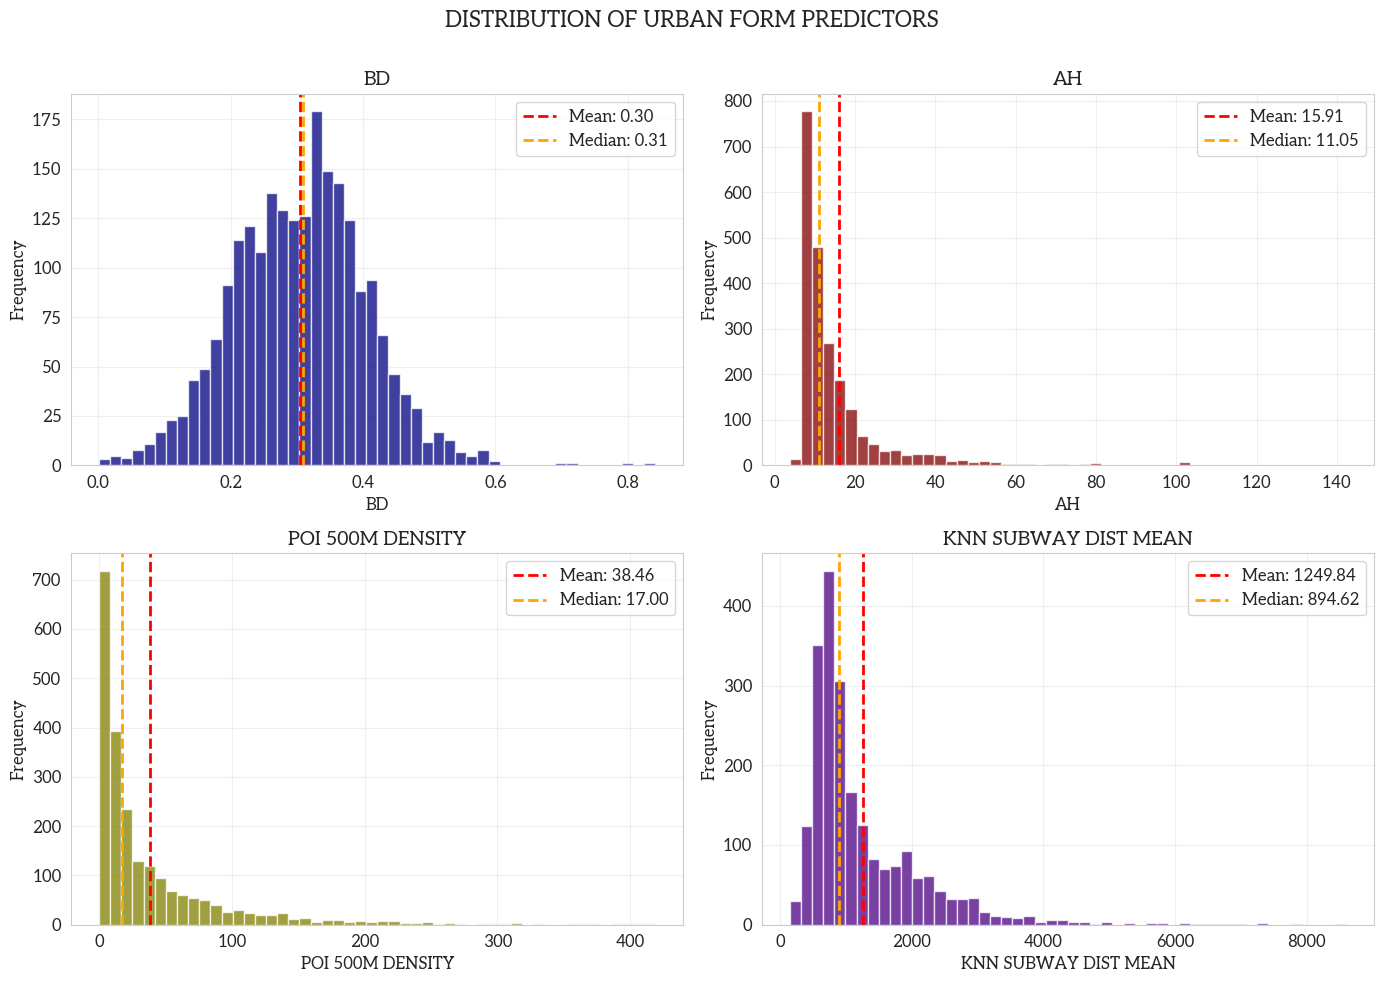

In [96]:
# Distribution viz of urban form predictors.
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle("DISTRIBUTION OF URBAN FORM PREDICTORS\n", fontsize = 16, fontweight = "bold")

colors = ["navy", "maroon", "olive", "indigo"]

for idx, (var, color) in enumerate(zip(urban_predictors, colors)):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].hist(df[var].dropna(),
                        bins = 50, edgecolor = "white", alpha = 0.75, color = color)
    
    axes[row, col].axvline(df[var].mean(), color = "red", linestyle = "--", linewidth = 2,
                           label = f"Mean: {df[var].mean():.2f}")
    
    axes[row, col].axvline(df[var].median(), color = "orange", linestyle = "--", linewidth = 2,
                           label = f"Median: {df[var].median():.2f}")
    
    axes[row, col].set_xlabel(var.replace("_", " ").upper())

    axes[row, col].set_ylabel("Frequency")

    axes[row, col].set_title(var.replace("_", " ").upper())

    axes[row, col].legend()
    
    axes[row, col].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

### 4.1 Correlation Analysis

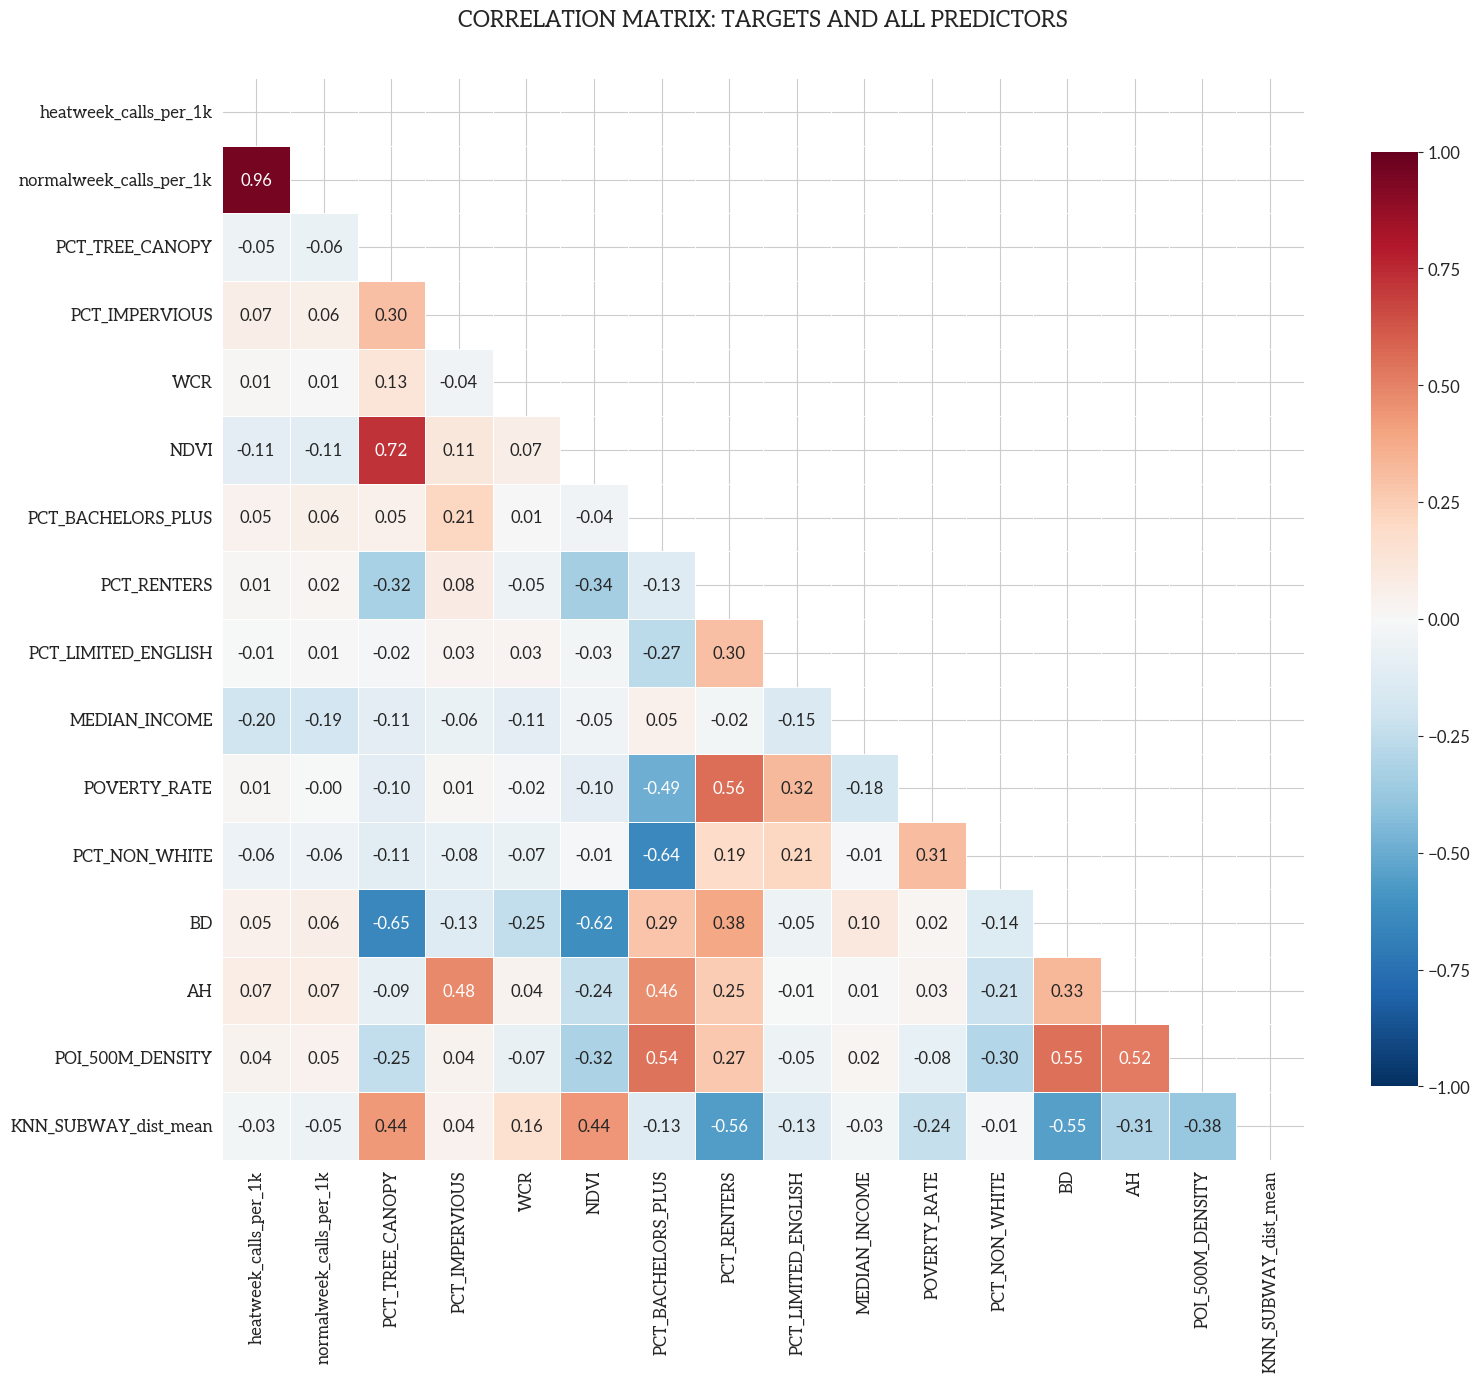

In [97]:
# Correlation matrix for all predictors and targets.
analysis_vars = targets + all_predictors
corr_matrix = df[analysis_vars].corr()

# Correlation matrix viz with heatmap.
fig, ax = plt.subplots(figsize = (16, 14))

mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

sns.heatmap(corr_matrix, mask = mask, annot = True, fmt = ".2f", cmap = "RdBu_r", 
            center = 0, vmin = -1, vmax = 1, square = True, linewidths = 0.5,
            cbar_kws = {"shrink": 0.8}, ax = ax)

ax.set_title("CORRELATION MATRIX: TARGETS AND ALL PREDICTORS\n", fontsize = 16, fontweight = "bold", pad = 20)

plt.tight_layout()
plt.show()

CORRELATIONS WITH TARGET VARIABLES

                      Heat Week Calls  Normal Week Calls  Difference
MEDIAN_INCOME               -0.198402          -0.185367   -0.013035
NDVI                        -0.105720          -0.113270    0.007550
AH                           0.072747           0.072362    0.000385
PCT_IMPERVIOUS               0.067571           0.060007    0.007564
PCT_NON_WHITE               -0.058319          -0.061150    0.002831
PCT_TREE_CANOPY             -0.054636          -0.063440    0.008804
BD                           0.048339           0.063436   -0.015096
PCT_BACHELORS_PLUS           0.045007           0.058821   -0.013814
POI_500M_DENSITY             0.035472           0.045540   -0.010068
KNN_SUBWAY_dist_mean        -0.028824          -0.048551    0.019727
PCT_RENTERS                  0.014312           0.020747   -0.006435
WCR                          0.014266           0.007046    0.007219
POVERTY_RATE                 0.014119          -0.001531    0.01565

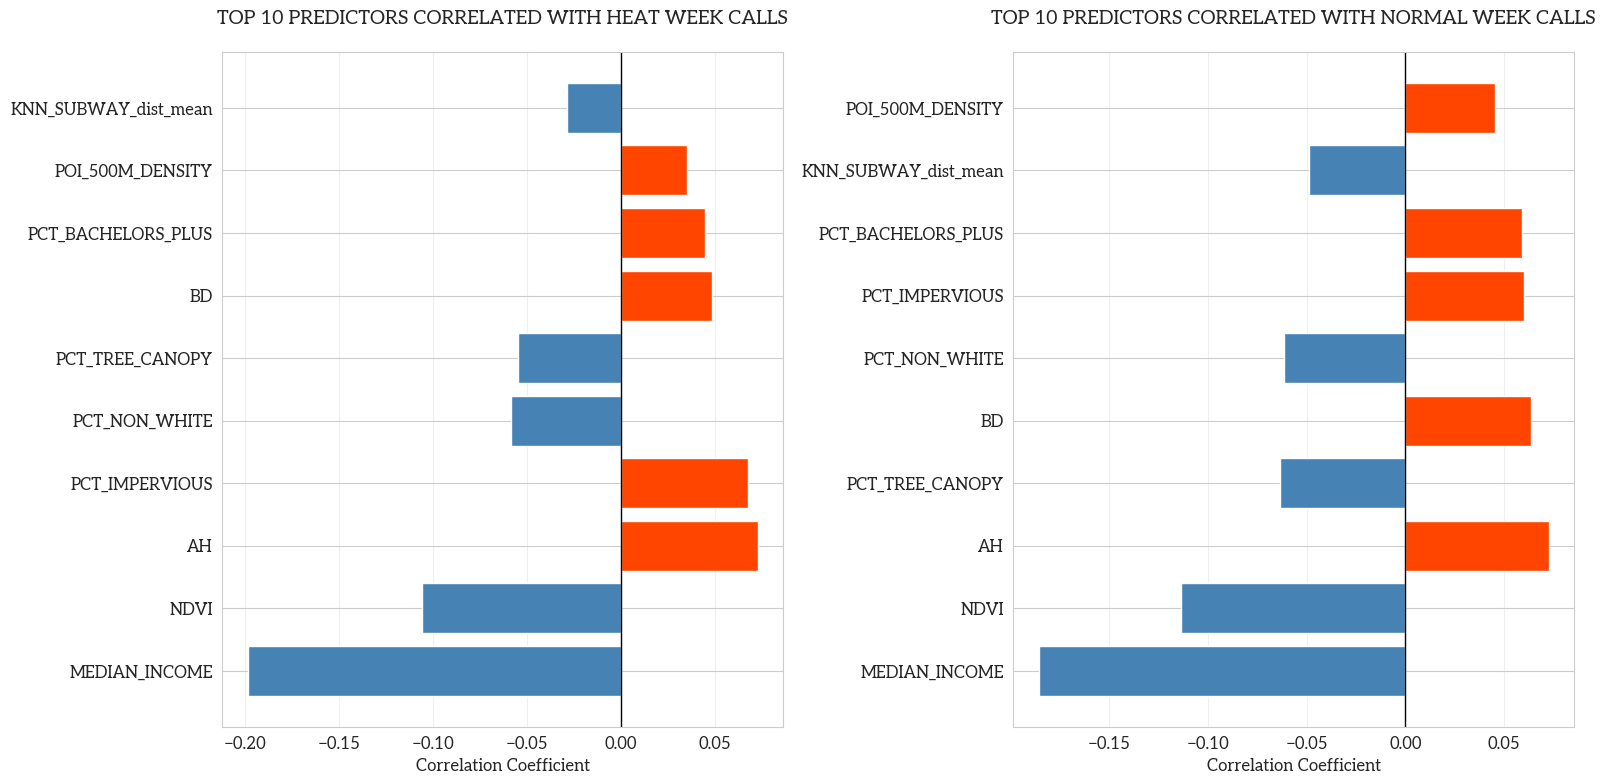

In [98]:
# Correlation of predictors with target variables.
print("CORRELATIONS WITH TARGET VARIABLES\n")

target_corrs = pd.DataFrame({
    "Heat Week Calls": corr_matrix["heatweek_calls_per_1k"][all_predictors],
    "Normal Week Calls": corr_matrix["normalweek_calls_per_1k"][all_predictors]
})

target_corrs["Difference"] = target_corrs["Heat Week Calls"] - target_corrs["Normal Week Calls"]

target_corrs = target_corrs.sort_values("Heat Week Calls", key = abs, ascending = False)

print(target_corrs.to_string())

# Visualize top correlations with targets.
fig, axes = plt.subplots(1, 2, figsize = (16, 8))

# Heat week correlations.
top_n = 10
top_heat = target_corrs["Heat Week Calls"].sort_values(key = abs, ascending = False).head(top_n)
colors_heat = ["orangered" if x > 0 else "steelblue" for x in top_heat.values]

axes[0].barh(range(len(top_heat)), top_heat.values,
             color = colors_heat, edgecolor = "white")

axes[0].set_yticks(range(len(top_heat)))

axes[0].set_yticklabels(top_heat.index)

axes[0].set_xlabel("Correlation Coefficient")

axes[0].set_title(f"TOP {top_n} PREDICTORS CORRELATED WITH HEAT WEEK CALLS\n", fontweight = "bold")

axes[0].axvline(0, color = "black", linewidth = 1)

axes[0].grid(alpha = 0.3, axis = "x")

# Normal week correlations.
top_normal = target_corrs["Normal Week Calls"].sort_values(key = abs, ascending = False).head(top_n)
colors_normal = ["orangered" if x > 0 else "steelblue" for x in top_normal.values]

axes[1].barh(range(len(top_normal)), top_normal.values,
             color = colors_normal, edgecolor = "white")

axes[1].set_yticks(range(len(top_normal)))

axes[1].set_yticklabels(top_normal.index)

axes[1].set_xlabel("Correlation Coefficient")

axes[1].set_title(f"TOP {top_n} PREDICTORS CORRELATED WITH NORMAL WEEK CALLS\n", fontweight = "bold")

axes[1].axvline(0, color = "black", linewidth = 1)

axes[1].grid(alpha = 0.3, axis = "x")

plt.tight_layout()
plt.show()

### 4.2 Scatterplots: Key Relationships

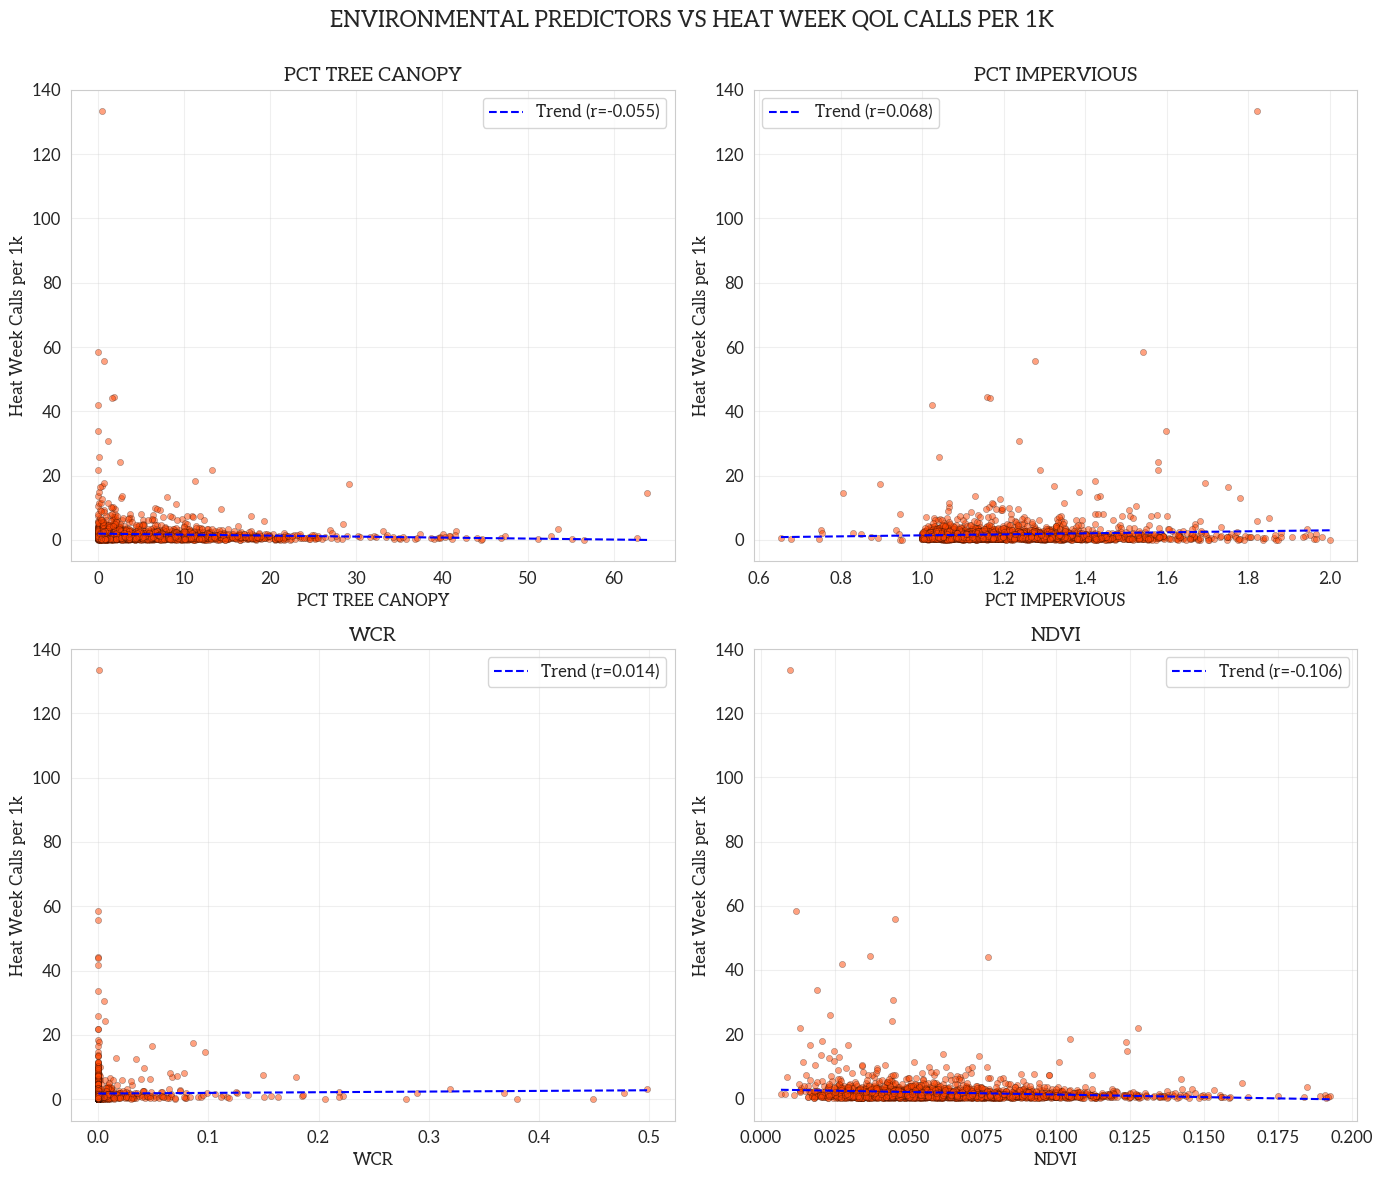

In [99]:
# Scatterplots of environmental predictors vs heat week calls.
fig, axes = plt.subplots(2, 2, figsize = (14, 12))
fig.suptitle("ENVIRONMENTAL PREDICTORS VS HEAT WEEK QOL CALLS PER 1K\n", fontsize = 16, fontweight = "bold")

for idx, var in enumerate(env_predictors):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].scatter(df[var], df["heatweek_calls_per_1k"], alpha = 0.5, s = 20,
                           color = "orangered", edgecolors = "black", linewidth = 0.3)
    
    # Add regression line.
    valid_mask = df[var].notna() & df["heatweek_calls_per_1k"].notna()

    if valid_mask.sum() > 1:
        z = np.polyfit(df.loc[valid_mask, var], df.loc[valid_mask, "heatweek_calls_per_1k"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[var].min(), df[var].max(), 100)
        axes[row, col].plot(x_line, p(x_line), "b--", linewidth = 1.5,
                            label = f"Trend (r={corr_matrix.loc[var, 'heatweek_calls_per_1k']:.3f})")
    
    axes[row, col].set_xlabel(var.replace("_", " ").upper())
    
    axes[row, col].set_ylabel("Heat Week Calls per 1k")

    axes[row, col].set_title(var.replace("_", " ").upper())

    axes[row, col].legend()

    axes[row, col].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

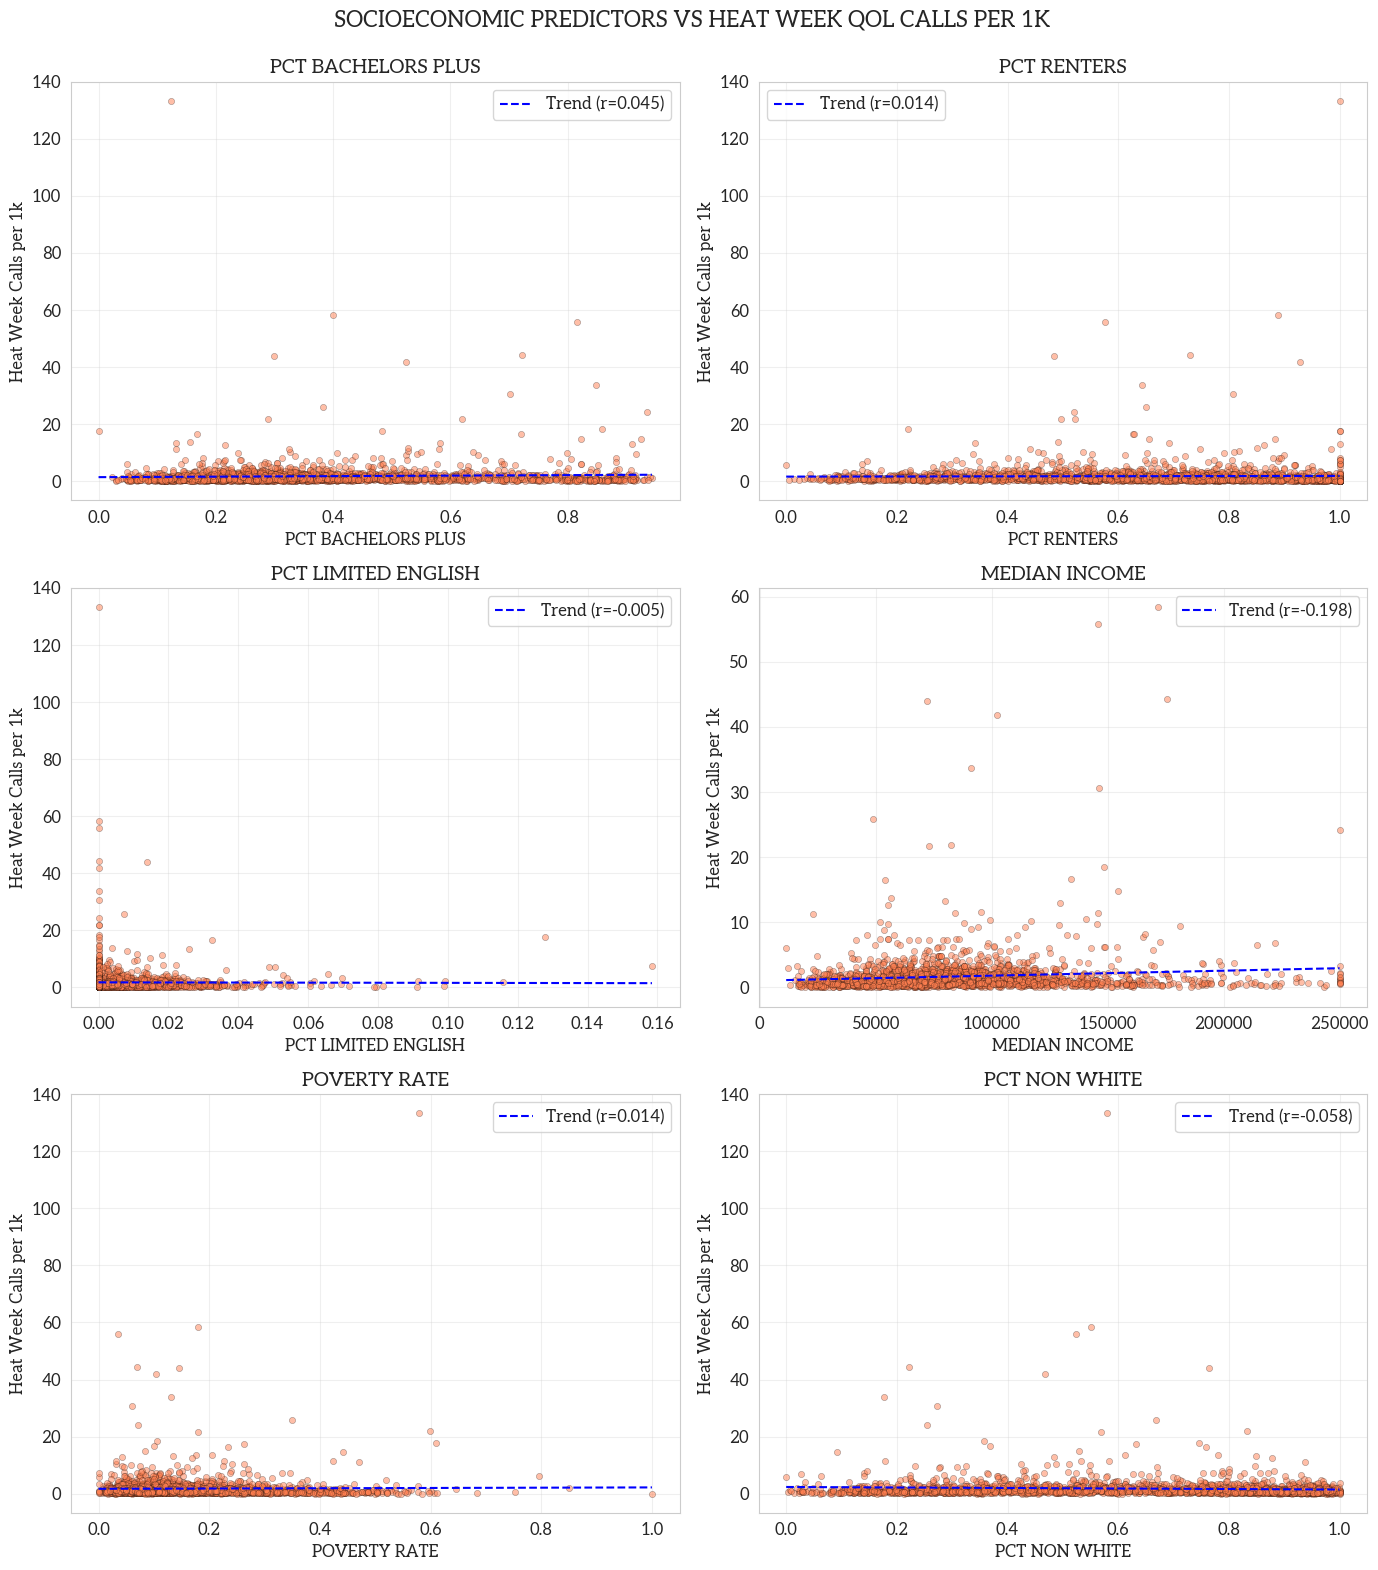

In [100]:
# Scatterplots of socioeconomic predictors vs heat week calls.
fig, axes = plt.subplots(3, 2, figsize = (14, 16))
fig.suptitle("SOCIOECONOMIC PREDICTORS VS HEAT WEEK QOL CALLS PER 1K\n", fontsize = 16, fontweight = "bold")

for idx, var in enumerate(acs_predictors):
    row = idx // 2
    col = idx % 2
    
    # Handle special case for MEDIAN_INCOME.
    if var == "MEDIAN_INCOME":
        plot_data = df[df[var] > 0]
    else:
        plot_data = df
    
    axes[row, col].scatter(plot_data[var], plot_data["heatweek_calls_per_1k"], alpha = 0.5, s = 20,
                           color = "coral", edgecolors = "black", linewidth = 0.3)
    
    # Add regression line.
    valid_mask = plot_data[var].notna() & plot_data["heatweek_calls_per_1k"].notna()
    
    if valid_mask.sum() > 1:
        z = np.polyfit(plot_data.loc[valid_mask, var], plot_data.loc[valid_mask, "heatweek_calls_per_1k"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_data[var].min(), plot_data[var].max(), 100)
        axes[row, col].plot(x_line, p(x_line), "b--", linewidth = 1.5,
                            label = f"Trend (r={corr_matrix.loc[var, 'heatweek_calls_per_1k']:.3f})")
    
    axes[row, col].set_xlabel(var.replace("_", " ").upper())

    axes[row, col].set_ylabel("Heat Week Calls per 1k")

    axes[row, col].set_title(var.replace("_", " ").upper())

    axes[row, col].legend()

    axes[row, col].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

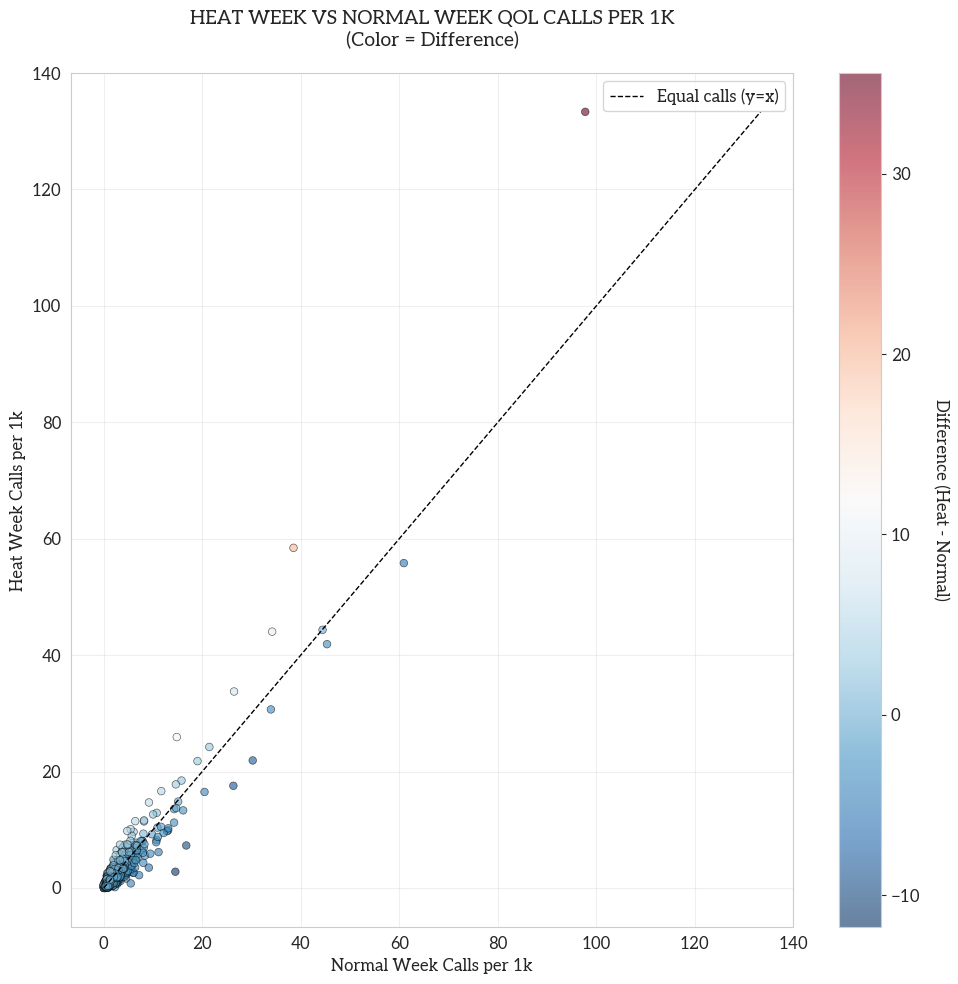

In [101]:
# Direct comparison scatterplot: Heat week vs Normal week calls.
fig, ax = plt.subplots(figsize = (10, 10))

df["calls_per_1k_diff"] = (
    df["heatweek_calls_per_1k"] - df["normalweek_calls_per_1k"]
)

ax.scatter(df["normalweek_calls_per_1k"], df["heatweek_calls_per_1k"], 
           alpha = 0.6, s = 30, c = df["calls_per_1k_diff"], 
           cmap = "RdBu_r", edgecolors = "black", linewidth = 0.5)

# Add diagonal reference line.
max_val = max(df["normalweek_calls_per_1k"].max(), df["heatweek_calls_per_1k"].max())

ax.plot([0, max_val], [0, max_val], "k--", linewidth = 1, label = "Equal calls (y=x)")

ax.set_xlabel("Normal Week Calls per 1k", fontsize = 12)

ax.set_ylabel("Heat Week Calls per 1k", fontsize = 12)

ax.set_title("HEAT WEEK VS NORMAL WEEK QOL CALLS PER 1K\n(Color = Difference)\n",
             fontsize = 14, fontweight = "bold")

ax.legend()

ax.grid(alpha = 0.3)

cbar = plt.colorbar(ax.collections[0], ax = ax)
cbar.set_label("Difference (Heat - Normal)", rotation = 270, labelpad = 20)

plt.tight_layout()
plt.show()

Tracts above diagonal (more calls during heat): 852 (38.3%)

Tracts below diagonal (fewer calls during heat): 1356 (60.9%)

Tracts on diagonal (equal calls): 17 (0.8%)

## 5. Multicollinearity Assessment

In [49]:
# Prepare data for VIF calculation.
# Drop rows with missing values in predictors.
vif_data = df[all_predictors].copy()

# Handle MEDIAN_INCOME placeholder values.
if "MEDIAN_INCOME" in vif_data.columns:
    vif_data.loc[vif_data["MEDIAN_INCOME"] < 0, "MEDIAN_INCOME"] = np.nan

vif_data = vif_data.dropna()

# Calculate VIF for each predictor.
vif_results = pd.DataFrame()
vif_results["Variable"] = all_predictors
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(all_predictors))]
vif_results = vif_results.sort_values("VIF", ascending = False)

# Add warning flags.
vif_results["Flag"] = vif_results["VIF"].apply(lambda x: "HIGH" if x > 10 else ("MODERATE" if x > 5 else "OK"))

print(vif_results.to_string(index = False))

            Variable       VIF     Flag
      PCT_IMPERVIOUS 53.829286     HIGH
                  BD 24.335496     HIGH
  PCT_BACHELORS_PLUS 19.086784     HIGH
         PCT_RENTERS 18.630721     HIGH
       MEDIAN_INCOME 17.783552     HIGH
                NDVI 12.859890     HIGH
       PCT_NON_WHITE 10.022016     HIGH
        POVERTY_RATE  6.621613 MODERATE
KNN_SUBWAY_dist_mean  5.033824 MODERATE
     PCT_TREE_CANOPY  4.609767       OK
                  AH  4.335747       OK
    POI_500M_DENSITY  3.327035       OK
 PCT_LIMITED_ENGLISH  1.580739       OK
                 WCR  1.130999       OK


VIF > 10 suggests high multicollinearity.

VIF > 5 may warrant investigation.

14 predictors and ~2200 observations.

7 variable(s) with VIF > 10 (high multicollinearity)

2 variable(s) with 5 < VIF <= 10 (moderate multicollinearity)

5 variable(s) with VIF <= 5 (acceptable)

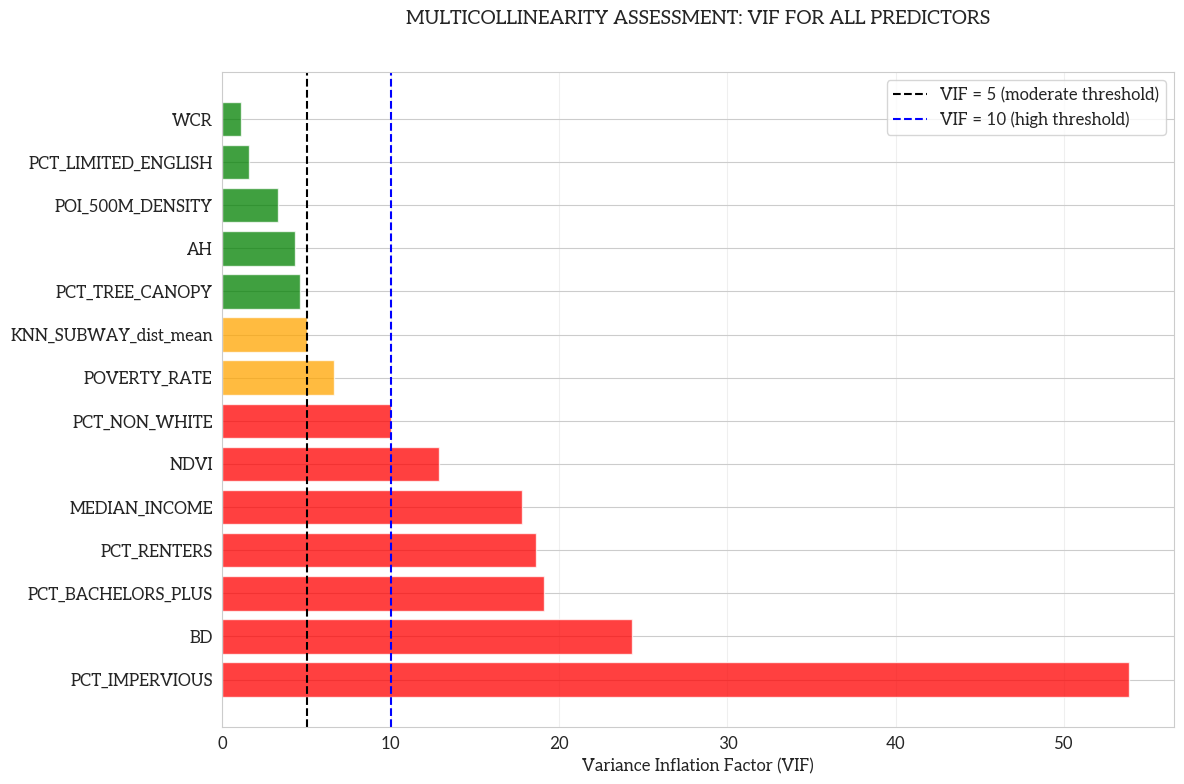

In [102]:
# VIF values viz.
fig, ax = plt.subplots(figsize = (12, 8))

colors = ["red" if x > 10 else "orange" if x > 5 else "green" for x in vif_results["VIF"]]

bars = ax.barh(range(len(vif_results)), vif_results["VIF"], color = colors, edgecolor = "white", alpha = 0.75)

ax.set_yticks(range(len(vif_results)))

ax.set_yticklabels(vif_results["Variable"])

ax.set_xlabel("Variance Inflation Factor (VIF)", fontsize = 12)

ax.set_title("MULTICOLLINEARITY ASSESSMENT: VIF FOR ALL PREDICTORS\n\n",
             fontsize = 14, fontweight = "bold")

ax.axvline(5, color = "black", linestyle = "--", linewidth = 1.5,
           label = "VIF = 5 (moderate threshold)")

ax.axvline(10, color = "blue", linestyle = "--", linewidth = 1.5,
           label = "VIF = 10 (high threshold)")

ax.legend()

ax.grid(alpha = 0.3, axis = "x")

plt.tight_layout()
plt.show()

## 6. Spatial Analysis and Visualization

### 6.1 Choropleth Maps of Key Variables

In [110]:
# Helper function to plot maps.
def plot_map(ax, column, cmap, title, gdf_source, vmin = None, vmax = None):
    gdf_source.plot(
        column = column,
        cmap = cmap,
        legend = True,
        ax = ax,
        linewidth = 0,
        edgecolor = "face",
        antialiased = False,
        rasterized = True,
        missing_kwds = {"color": "lightgrey"},
        vmin = vmin,
        vmax = vmax
    )
    
    boundaries.plot(
        ax = ax,
        facecolor = "none",
        edgecolor = "#9b9e98",
        linewidth = 1
    )

    ax.set_title(
        title,
        fontsize = 20,
        fontproperties = font_aleo,
        fontweight = "bold",
        pad = 12
    )

    ax.axis("off")

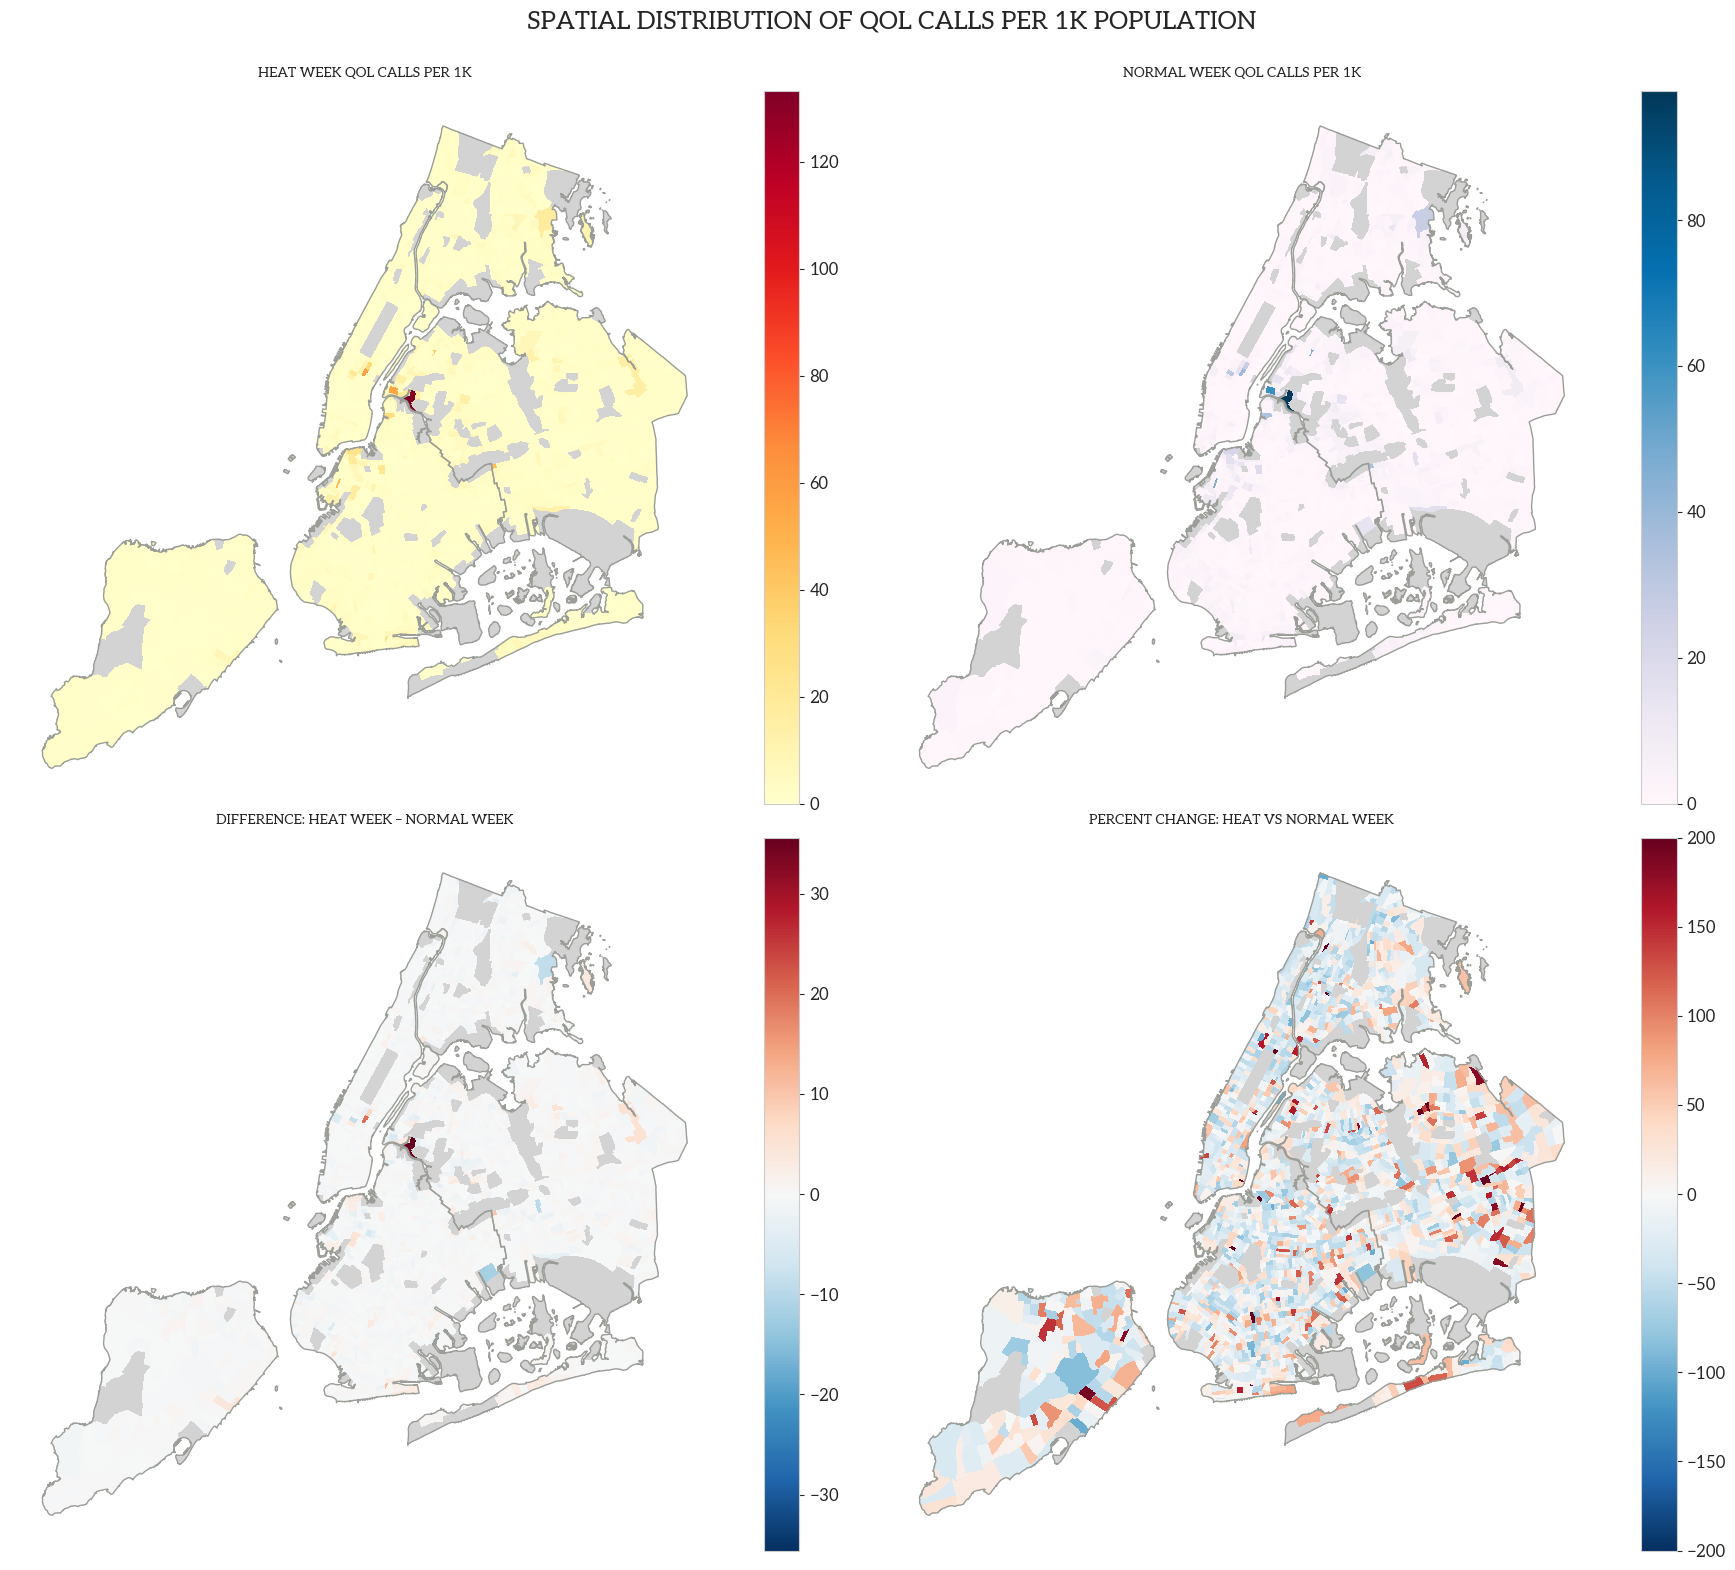

In [111]:
fig, axes = plt.subplots(2, 2, figsize = (18, 16))
fig.suptitle(
    "SPATIAL DISTRIBUTION OF QOL CALLS PER 1K POPULATION\n\n",
    fontsize = 18,
    fontweight = "bold"
)

# 1. Heat week calls.
plot_map(
    axes[0, 0],
    "heatweek_calls_per_1k",
    "YlOrRd",
    "HEAT WEEK QOL CALLS PER 1K",
    gdf
)

# 2. Normal week calls.
plot_map(
    axes[0, 1],
    "normalweek_calls_per_1k",
    "PuBu",
    "NORMAL WEEK QOL CALLS PER 1K",
    gdf
)

# 3. Difference (heat – normal).
gdf["calls_per_1k_diff"] = (
    gdf["heatweek_calls_per_1k"] - gdf["normalweek_calls_per_1k"]
)

diff = gdf["calls_per_1k_diff"]
max_abs = np.nanmax(np.abs(diff))

plot_map(
    axes[1, 0],
    "calls_per_1k_diff",
    "RdBu_r",
    "DIFFERENCE: HEAT WEEK – NORMAL WEEK",
    gdf,
    vmin = -max_abs,
    vmax = max_abs
)

# Percent change.
gdf["pct_change"] = (
    (gdf["heatweek_calls_per_1k"] - gdf["normalweek_calls_per_1k"])
    / gdf["normalweek_calls_per_1k"].replace(0, np.nan)
) * 100

pct = gdf["pct_change"].clip(-200, 200)
gdf["pct_change_clipped"] = pct

plot_map(
    axes[1, 1],
    "pct_change",
    "RdBu_r",
    "PERCENT CHANGE: HEAT VS NORMAL WEEK",
    gdf,
    vmin = -200,
    vmax = 200
)

plt.tight_layout()
plt.show()


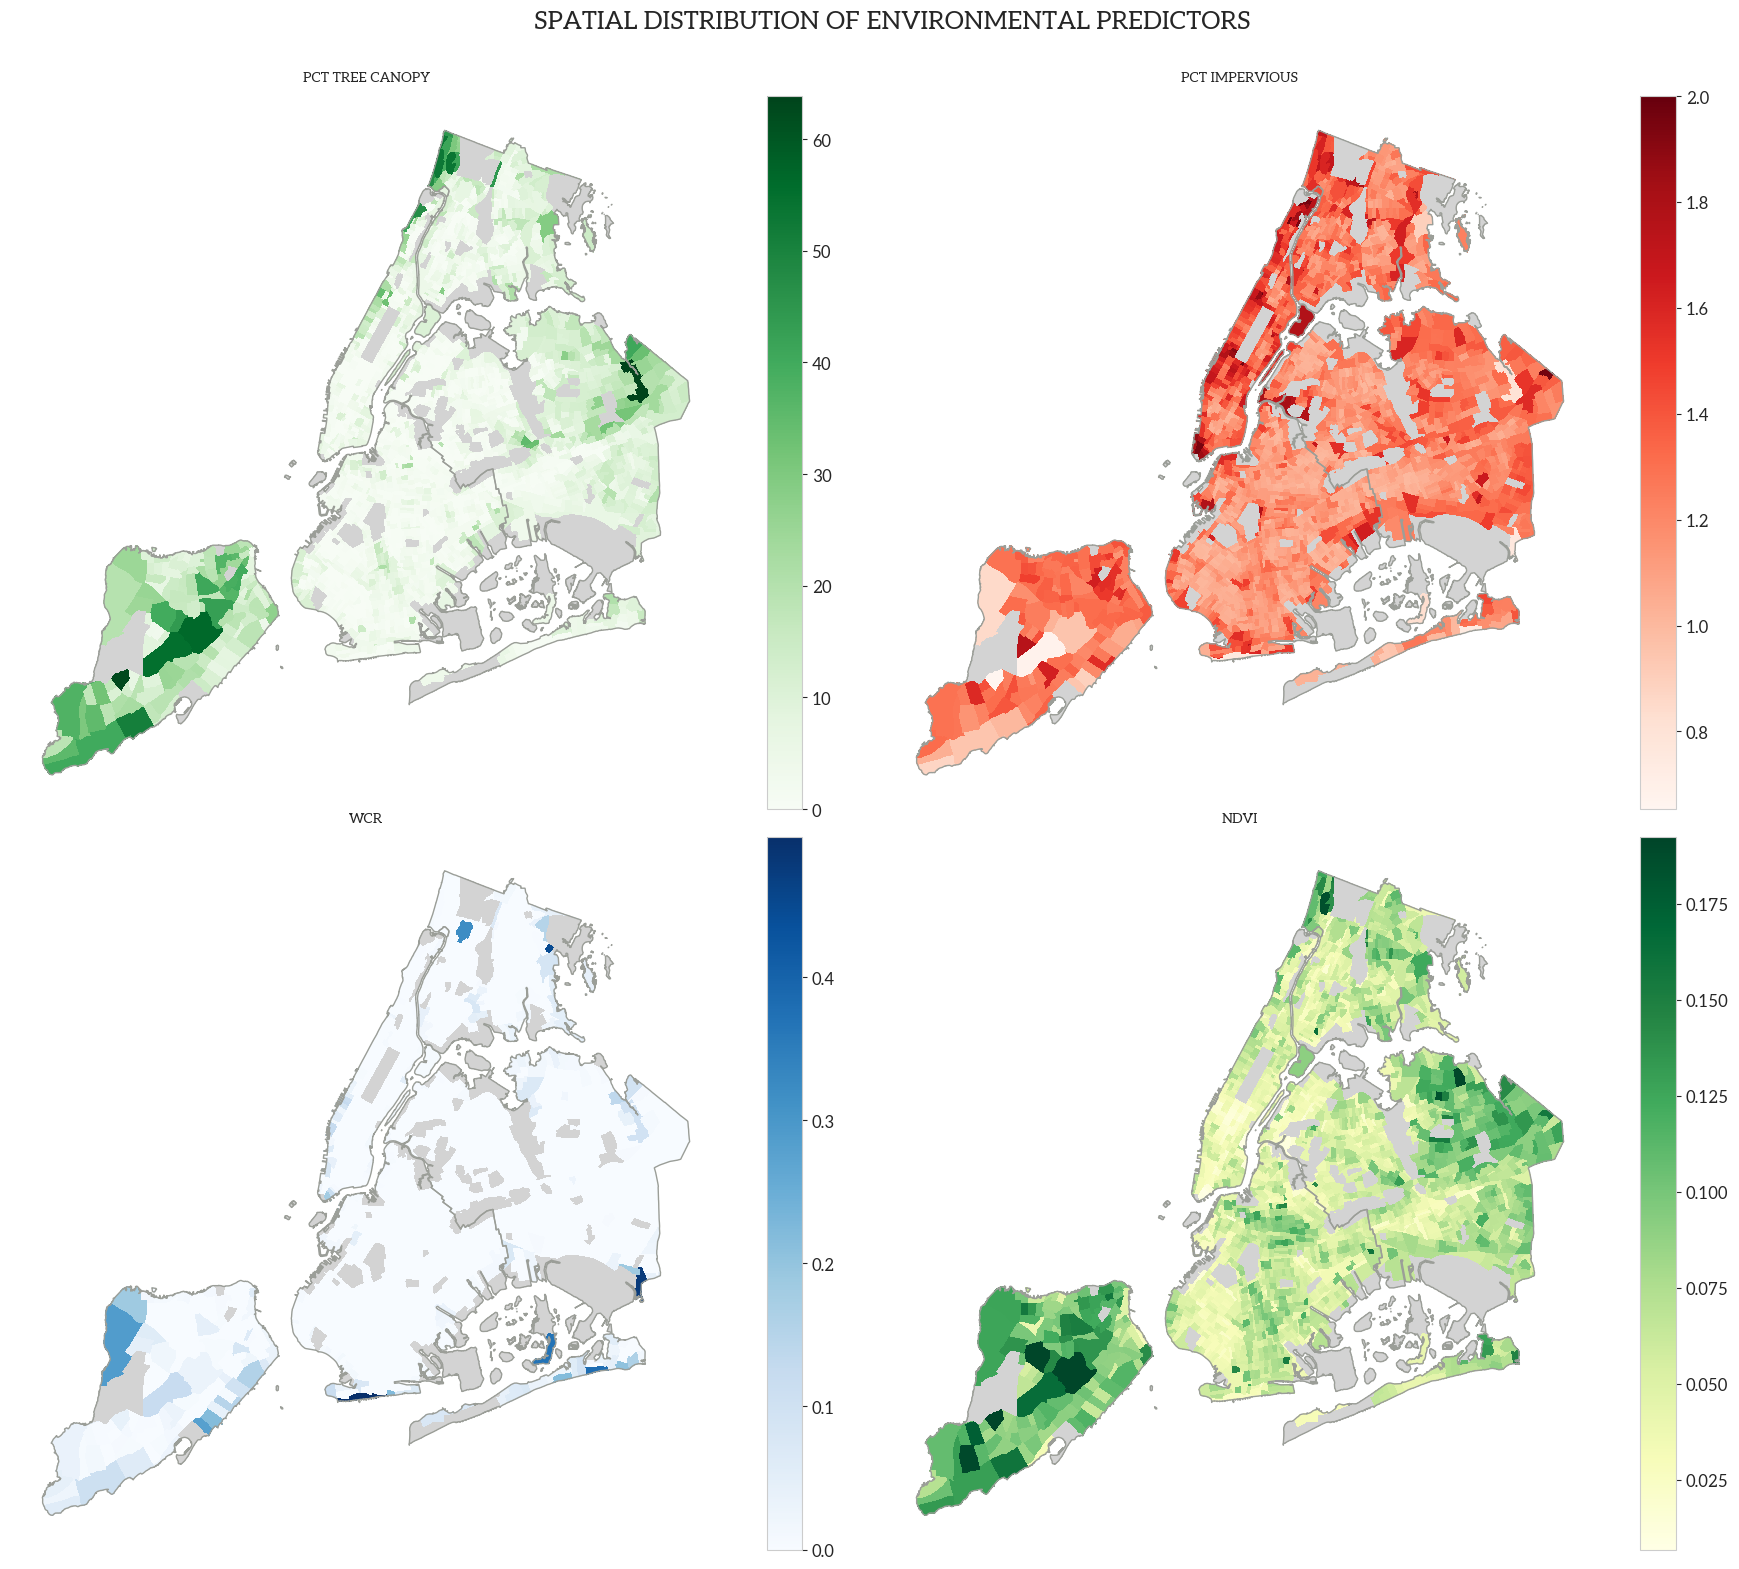

In [113]:
fig, axes = plt.subplots(2, 2, figsize = (18, 16))
fig.suptitle(
    "SPATIAL DISTRIBUTION OF ENVIRONMENTAL PREDICTORS\n\n",
    fontsize = 18,
    fontweight = "bold"
)

cmaps = ["Greens", "Reds", "Blues", "YlGn"]

for idx, (var, cmap) in enumerate(zip(env_predictors, cmaps)):
    row = idx // 2
    col = idx % 2
    
    title = var.replace("_", " ").upper()
    plot_map(axes[row, col], var, cmap, title, gdf)

plt.tight_layout()
plt.show()

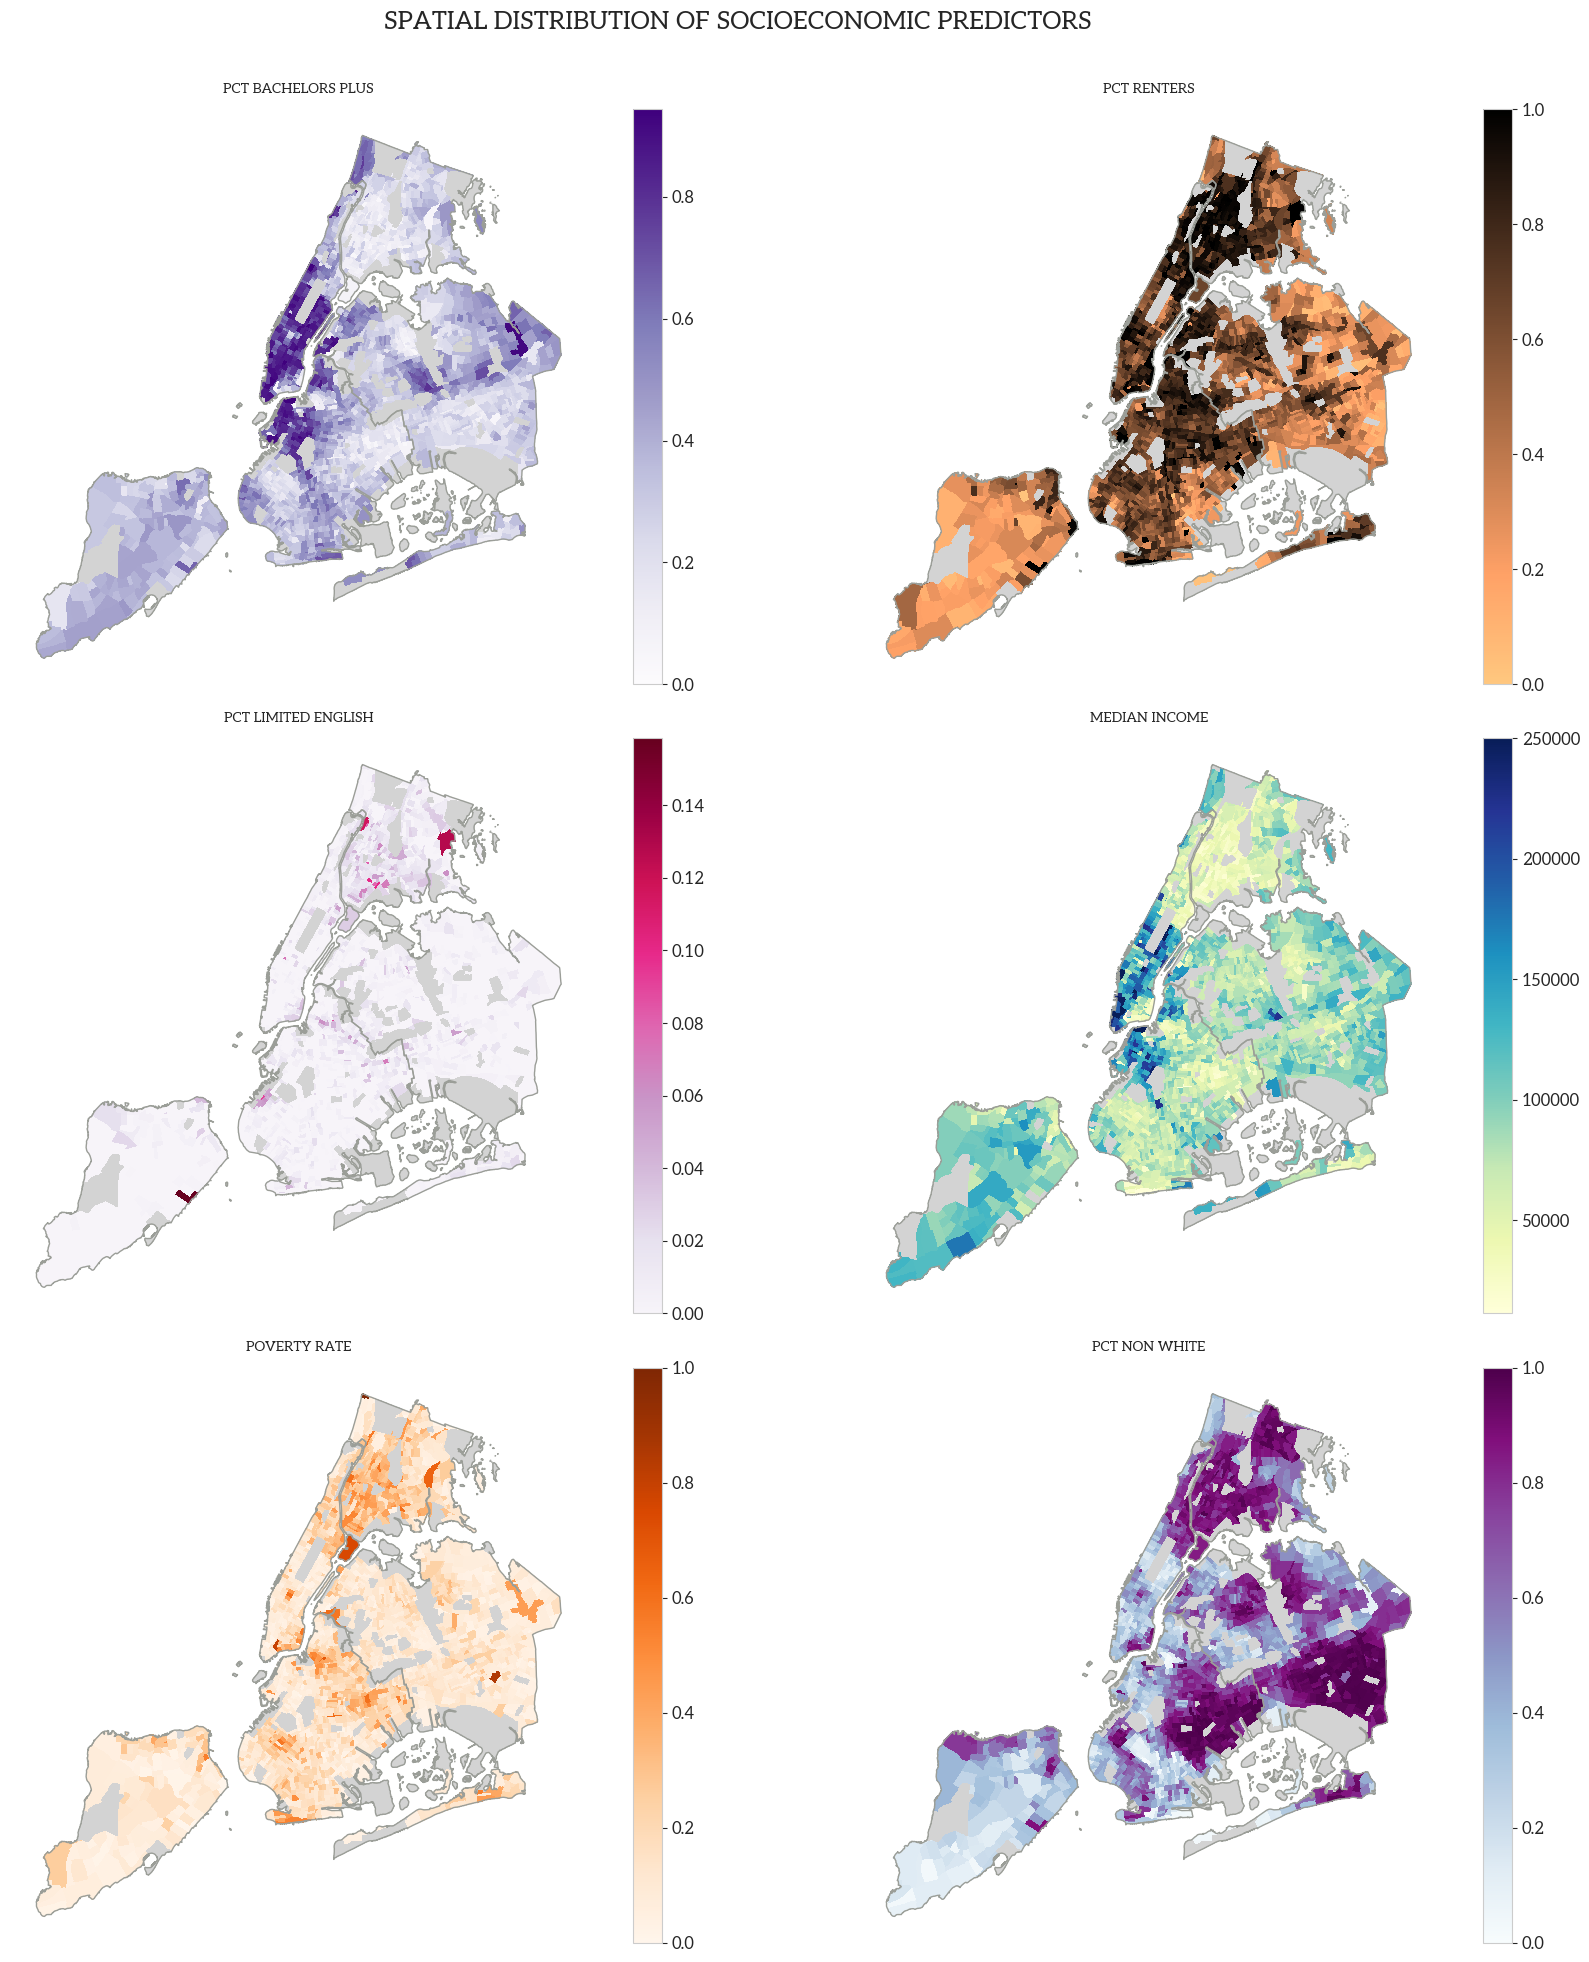

In [114]:
fig, axes = plt.subplots(3, 2, figsize = (18, 20))
fig.suptitle(
    "SPATIAL DISTRIBUTION OF SOCIOECONOMIC PREDICTORS\n\n",
    fontsize = 18,
    fontweight = "bold"
)

cmaps = ["Purples", "copper_r", "PuRd", "YlGnBu", "Oranges", "BuPu"]

for idx, (var, cmap) in enumerate(zip(acs_predictors, cmaps)):
    row = idx // 2
    col = idx % 2
    
    # Handle MEDIAN_INCOME.
    if var == "MEDIAN_INCOME":
        plot_gdf = gdf.copy()
        plot_gdf.loc[plot_gdf[var] < 0, var] = np.nan
    else:
        plot_gdf = gdf
    
    title = var.replace("_", " ").upper()
    plot_map(axes[row, col], var, cmap, title, plot_gdf)

plt.tight_layout()
plt.show()

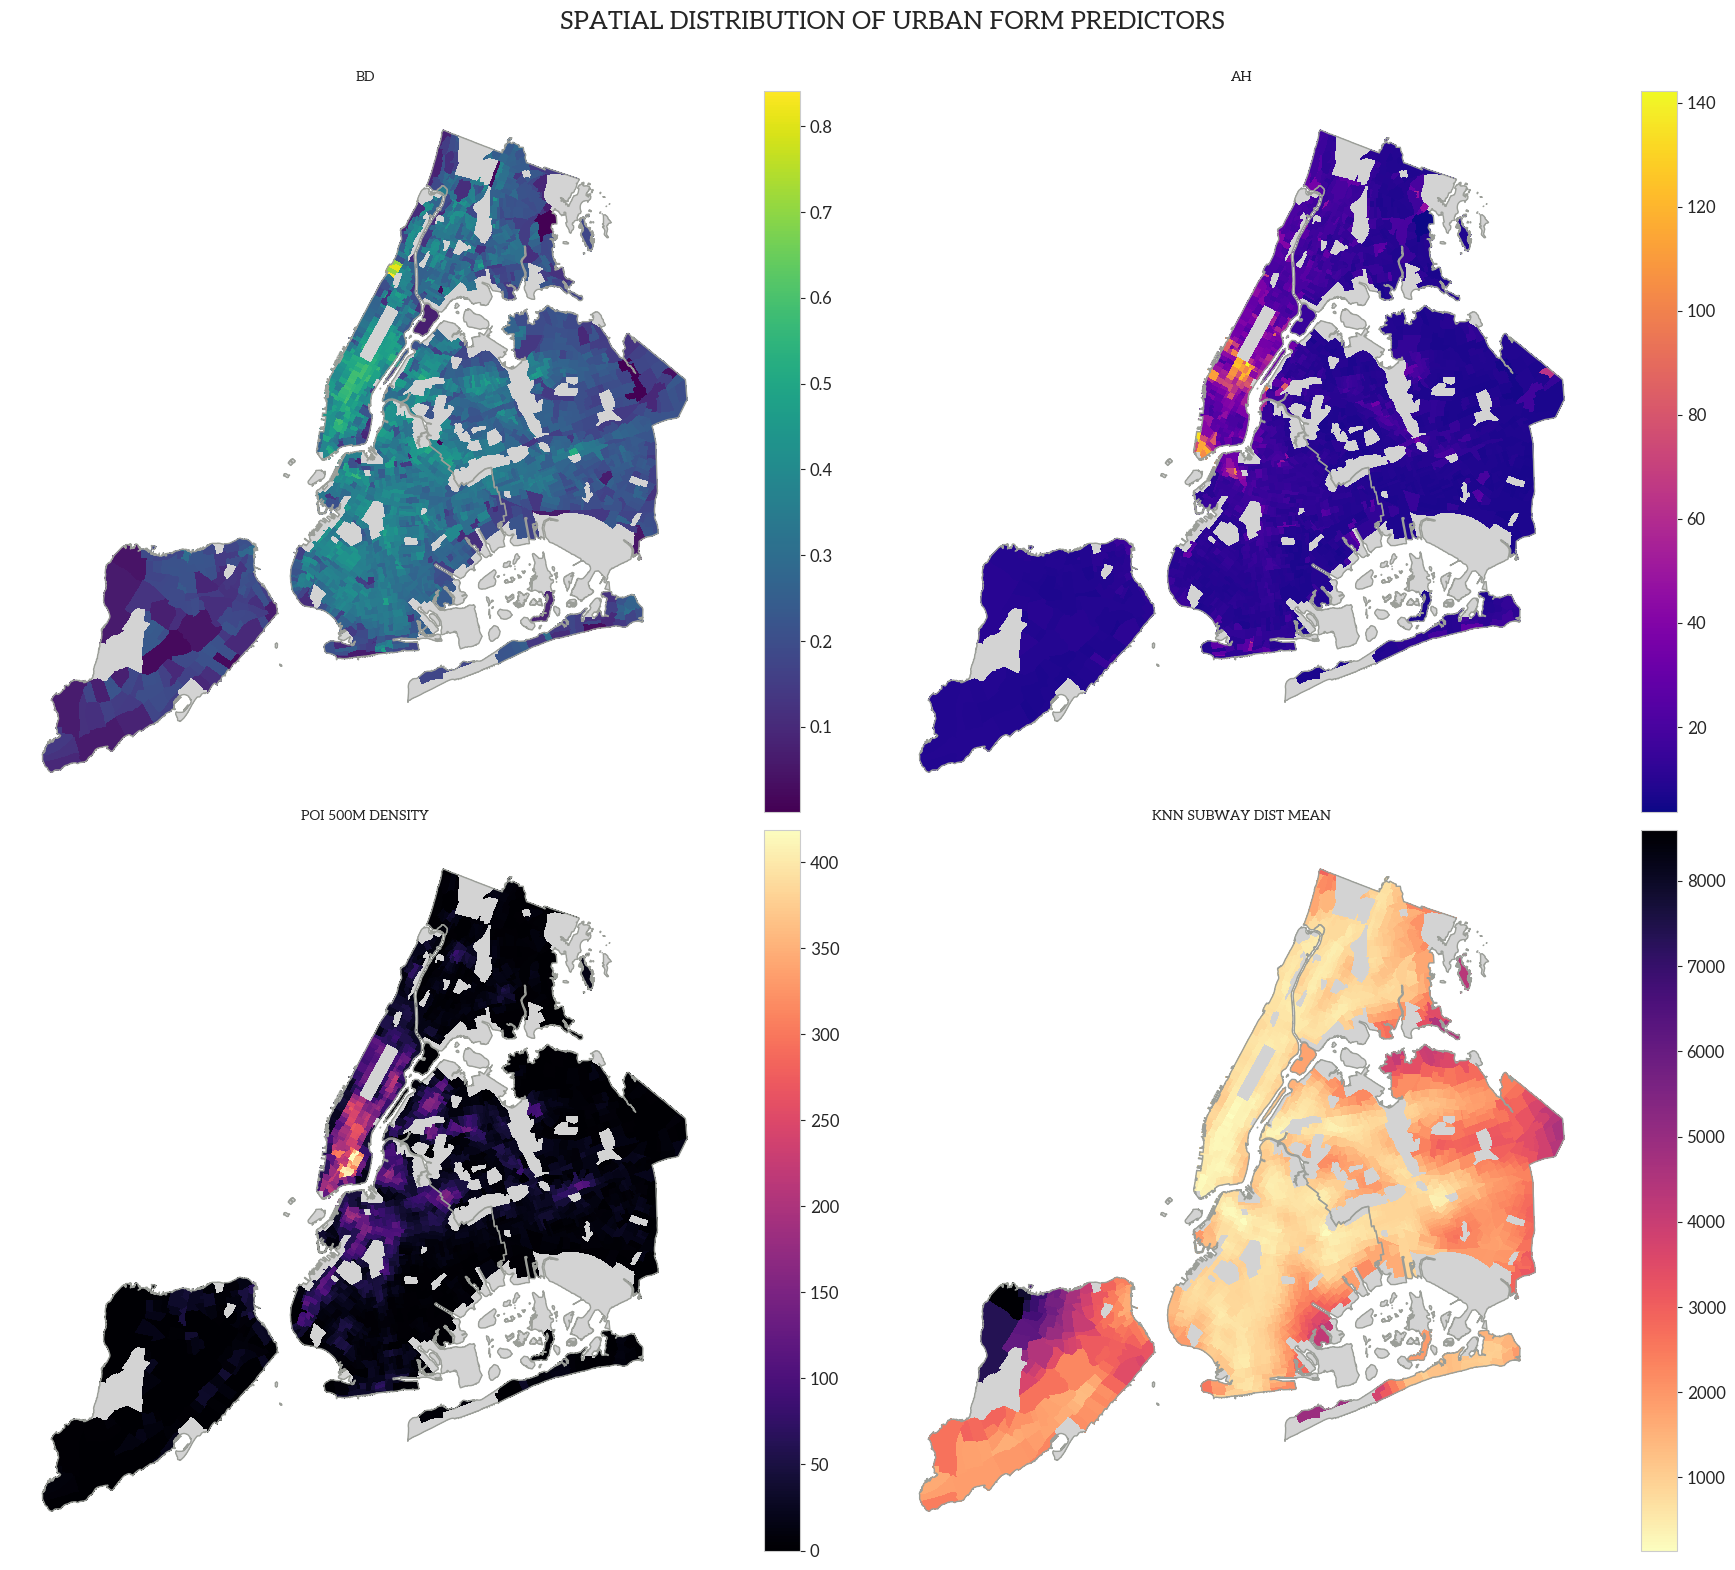

In [115]:
fig, axes = plt.subplots(2, 2, figsize = (18, 16))
fig.suptitle(
    "SPATIAL DISTRIBUTION OF URBAN FORM PREDICTORS\n\n",
    fontsize = 18,
    fontweight = "bold"
)

cmaps = ["viridis", "plasma", "magma", "magma_r"]

for idx, (var, cmap) in enumerate(zip(urban_predictors, cmaps)):
    row = idx // 2
    col = idx % 2
    
    title = var.replace("_", " ").upper()
    plot_map(axes[row, col], var, cmap, title, gdf)

plt.tight_layout()
plt.show()

### 6.2 Spatial Autocorrelation Analysis

In [80]:
# Prepare spatial weights matrix using Queen contiguity.
# Remove tracts without data for spatial weights calculation.
gdf_complete = gdf.dropna(subset = ["heatweek_calls_per_1k"])
w = Queen.from_dataframe(gdf_complete)
w.transform = "r"  # Row-standardization.

# Calculate Moran's I for selected variables.
test_vars = targets + ["calls_per_1k_diff"] + env_predictors[:2] + acs_predictors[:2]
morans_results = []

for var in test_vars:
    if var in gdf_complete.columns and gdf_complete[var].notna().sum() > 0:
        try:
            mi = Moran(gdf_complete[var], w)
            morans_results.append({
                "Variable": var,
                "Moran's I": mi.I,
                "Expected I": mi.EI,
                "p-value": mi.p_sim,
                "Significant": "Yes" if mi.p_sim < 0.05 else "No"
            })
        except:
            continue

morans_df = pd.DataFrame(morans_results)
print(morans_df.to_string(index = False))

('WARNING: ', 815, ' is an island (no neighbors)')
('WARNING: ', 1635, ' is an island (no neighbors)')
('WARNING: ', 2036, ' is an island (no neighbors)')
               Variable  Moran's I  Expected I  p-value Significant
  heatweek_calls_per_1k   0.163050    -0.00045    0.001         Yes
normalweek_calls_per_1k   0.192314    -0.00045    0.001         Yes
      calls_per_1k_diff   0.015316    -0.00045    0.070          No
        PCT_TREE_CANOPY   0.639520    -0.00045    0.001         Yes
         PCT_IMPERVIOUS   0.557429    -0.00045    0.001         Yes
     PCT_BACHELORS_PLUS   0.791766    -0.00045    0.001         Yes
            PCT_RENTERS   0.654061    -0.00045    0.001         Yes


Spatial weights created for 2225 tracts.

Average number of neighbors: 5.87.

Moran's I ranges from -1 (dispersed) to +1 (clustered). Values near 0 indicate random spatial pattern.

Positive Moran's I indicates spatial clustering (similar values near each other).

Negative Moran's I indicates spatial dispersion (dissimilar values near each other).

p-value < 0.05 indicates statistically significant spatial pattern.


LISA Cluster Summary:
lisa_label
Not Significant    1754
LL (Low-Low)        324
HH (High-High)       86
LH (Low-High)        44
HL (High-Low)        17


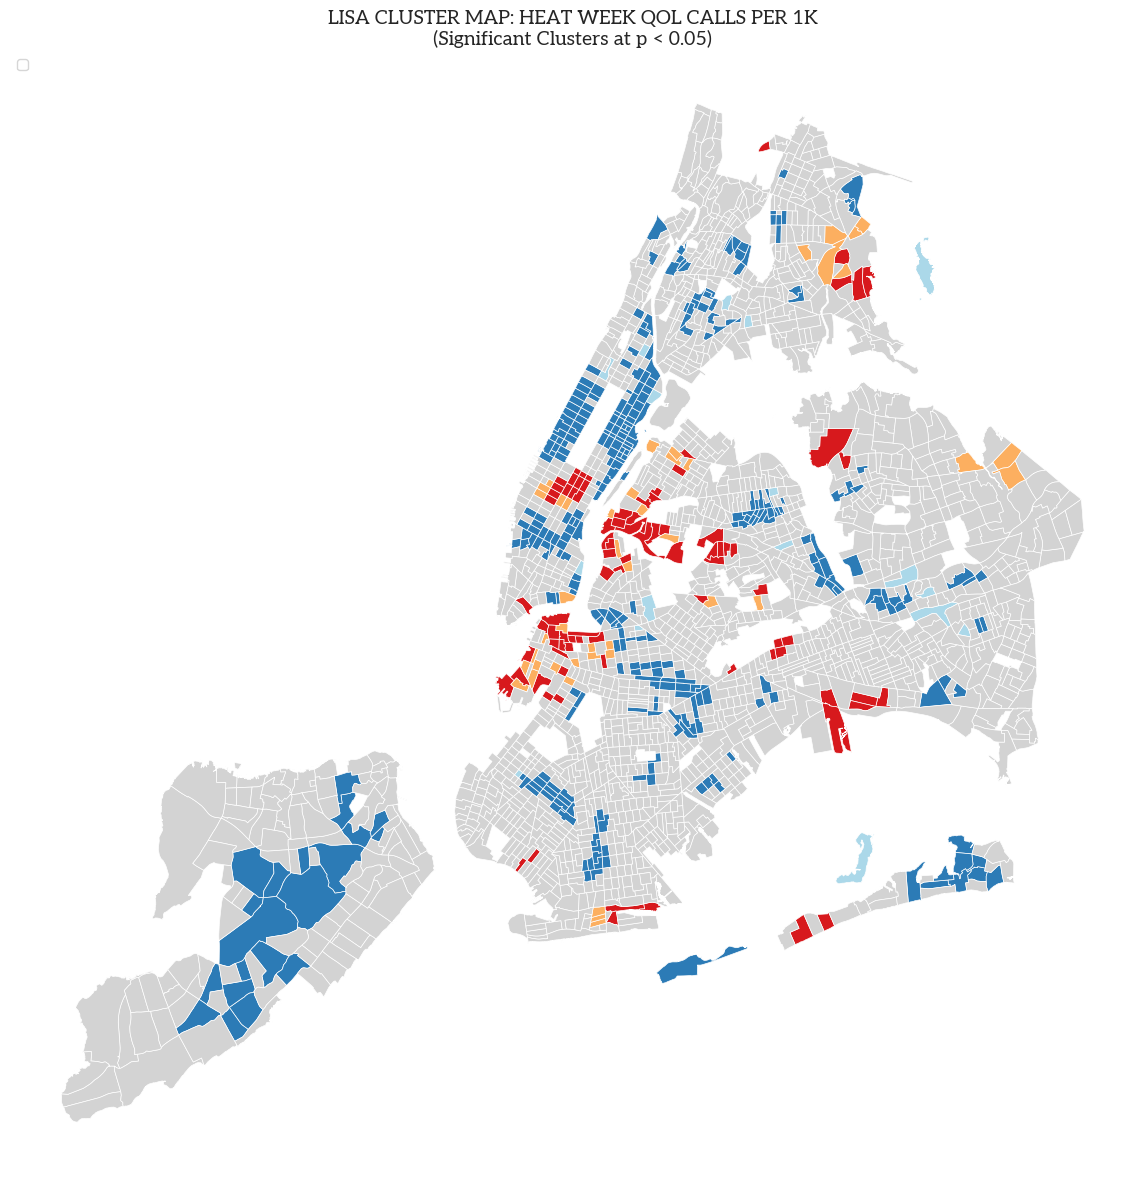

In [82]:
# Calculate Local Moran's I.
lisa = Moran_Local(gdf_complete["heatweek_calls_per_1k"], w)

# Add LISA results to geodataframe.
gdf_complete["lisa_cluster"] = lisa.q
gdf_complete["lisa_pval"] = lisa.p_sim
gdf_complete["lisa_sig"] = (lisa.p_sim < 0.05).astype(int)

# Create cluster labels.
cluster_labels = {
    1: "HH (High-High)",
    2: "LH (Low-High)",
    3: "LL (Low-Low)",
    4: "HL (High-Low)",
    0: "Not Significant"
}

# Filter for significant clusters only.
gdf_complete["lisa_label"] = gdf_complete.apply(
    lambda row: cluster_labels[row["lisa_cluster"]] if row["lisa_sig"] == 1 else cluster_labels[0],
    axis = 1
)

# Summary of clusters.
cluster_summary = gdf_complete["lisa_label"].value_counts()
print("\nLISA Cluster Summary:")
print(cluster_summary.to_string())

# Map LISA clusters.
fig, ax = plt.subplots(figsize = (14, 12))

# Define colors for clusters.
cluster_colors = {
    "HH (High-High)": "#d7191d",
    "LL (Low-Low)": "#2c7bb6",
    "LH (Low-High)": "#fcaf60",
    "HL (High-Low)": "#abd8e9",
    "Not Significant": "lightgray"
}

for label, color in cluster_colors.items():
    subset = gdf_complete[gdf_complete["lisa_label"] == label]
    if len(subset) > 0:
        subset.plot(ax = ax, color = color, edgecolor = "white", linewidth = 0.5, label = label)

ax.set_title("LISA CLUSTER MAP: HEAT WEEK QOL CALLS PER 1K\n(Significant Clusters at p < 0.05)", 
             fontsize = 14, fontweight = "bold")
ax.axis("off")
ax.legend(loc = "upper left", fontsize = 10)

plt.tight_layout()
plt.show()

HH (High-High): Hot spots - high values surrounded by high values.

LL (Low-Low): Cold spots - low values surrounded by low values.

LH (Low-High): Spatial outliers - low values surrounded by high values.

HL (High-Low): Spatial outliers - high values surrounded by low values.

### 6.3 Bivariate Choropleth Maps

In [83]:
# Function to create bivariate choropleth map.
def create_bivariate_map(gdf, var1, var2, title, var1_label, var2_label):
    """
    Create bivariate choropleth map showing relationship between two variables.
    
    Parameters:
    - gdf: GeoDataFrame with spatial data.
    - var1: First variable name (string).
    - var2: Second variable name (string).
    - title: Map title (string).
    - var1_label: Label for first variable (string).
    - var2_label: Label for second variable (string).
    """
    
    # Create copy and remove missing values.
    plot_gdf = gdf[[var1, var2, "geometry"]].copy().dropna()
    
    # Classify each variable into 3 quantiles.
    plot_gdf[f"{var1}_class"] = pd.qcut(plot_gdf[var1], q = 3, labels = ["Low", "Med", "High"], duplicates = "drop")
    plot_gdf[f"{var2}_class"] = pd.qcut(plot_gdf[var2], q = 3, labels = ["Low", "Med", "High"], duplicates = "drop")
    
    # Create bivariate class.
    plot_gdf["bivar_class"] = plot_gdf[f"{var1}_class"].astype(str) + "-" + plot_gdf[f"{var2}_class"].astype(str)
    
    # Define color scheme for 3x3 bivariate map.
    color_dict = {
        "Low-Low": "#e8e8e8",
        "Low-Med": "#ace4e4",
        "Low-High": "#5ac8c8",
        "Med-Low": "#dfb0d6",
        "Med-Med": "#a5add3",
        "Med-High": "#5698b9",
        "High-Low": "#be64ac",
        "High-Med": "#8c62aa",
        "High-High": "#3b4994"
    }
    
    # Map colors.
    plot_gdf["color"] = plot_gdf["bivar_class"].map(color_dict)
    
    # Create plot.
    fig, ax = plt.subplots(figsize = (14, 12))

    plot_gdf.plot(color = plot_gdf["color"], ax = ax, edgecolor = "white", linewidth = 0.5)

    ax.set_title(title, fontsize = 14, fontweight = "bold")

    ax.axis("off")
    
    legend_elements = []

    for key, color in color_dict.items():
        legend_elements.append(Rectangle((0, 0), 1, 1, facecolor = color, edgecolor = "none", label = key))
    
    ax.legend(handles = legend_elements, title = f"{var1_label} - {var2_label}", 
              loc = "upper left", fontsize = 8, ncol = 3)
    
    plt.tight_layout()
    plt.show()
    
    return plot_gdf

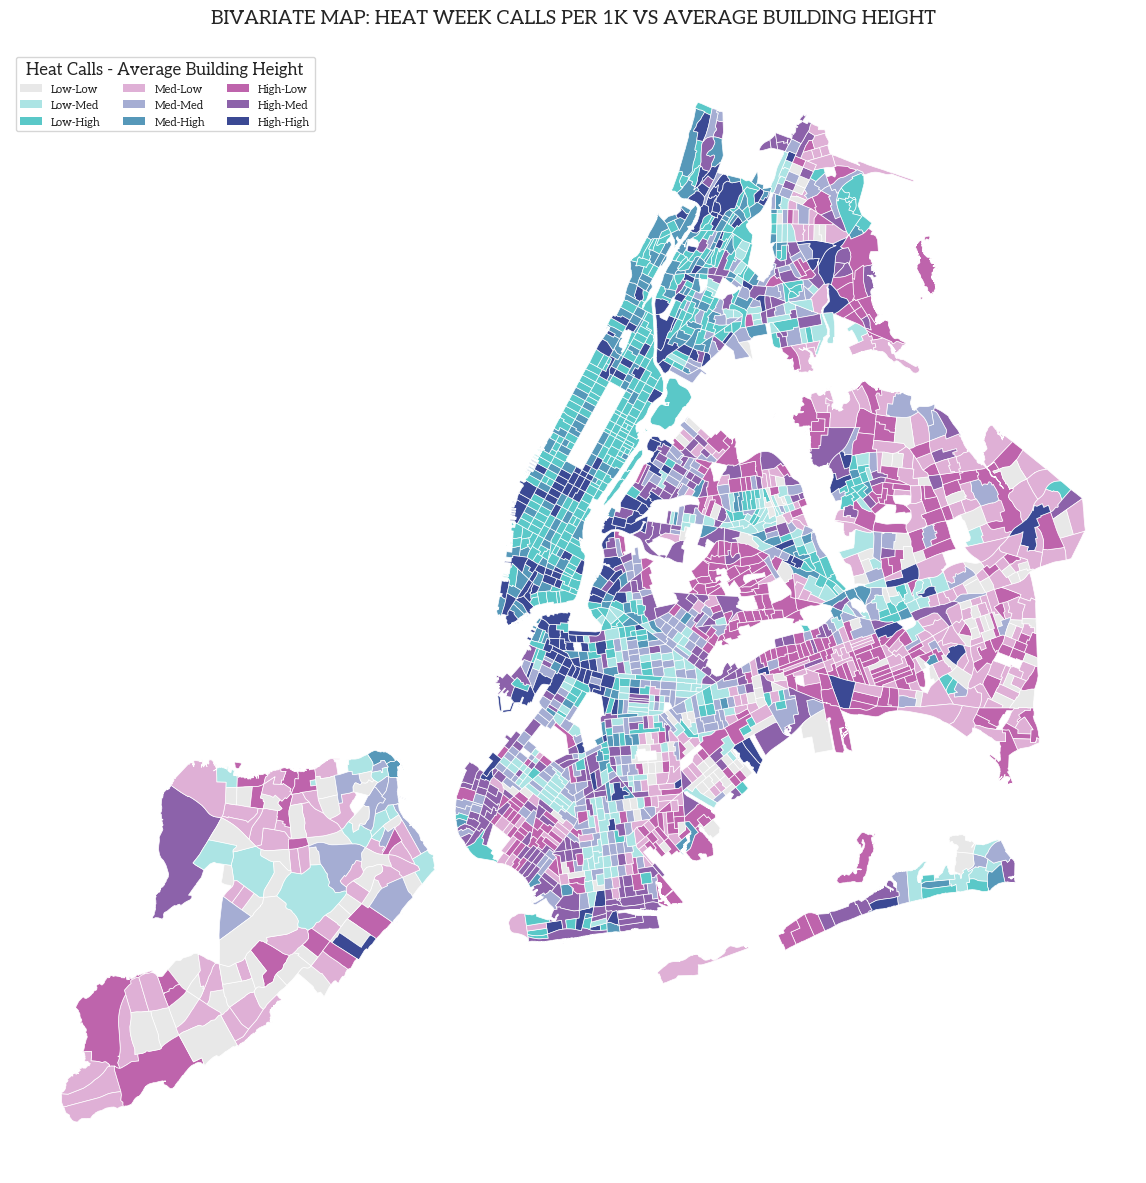

In [84]:
# Bivariate map: Heat week calls vs Average building height.
bivar_gdf1 = create_bivariate_map(
    gdf,
    "heatweek_calls_per_1k",
    "AH",
    "BIVARIATE MAP: HEAT WEEK CALLS PER 1K VS AVERAGE BUILDING HEIGHT\n",
    "Heat Calls",
    "Average Building Height"
)

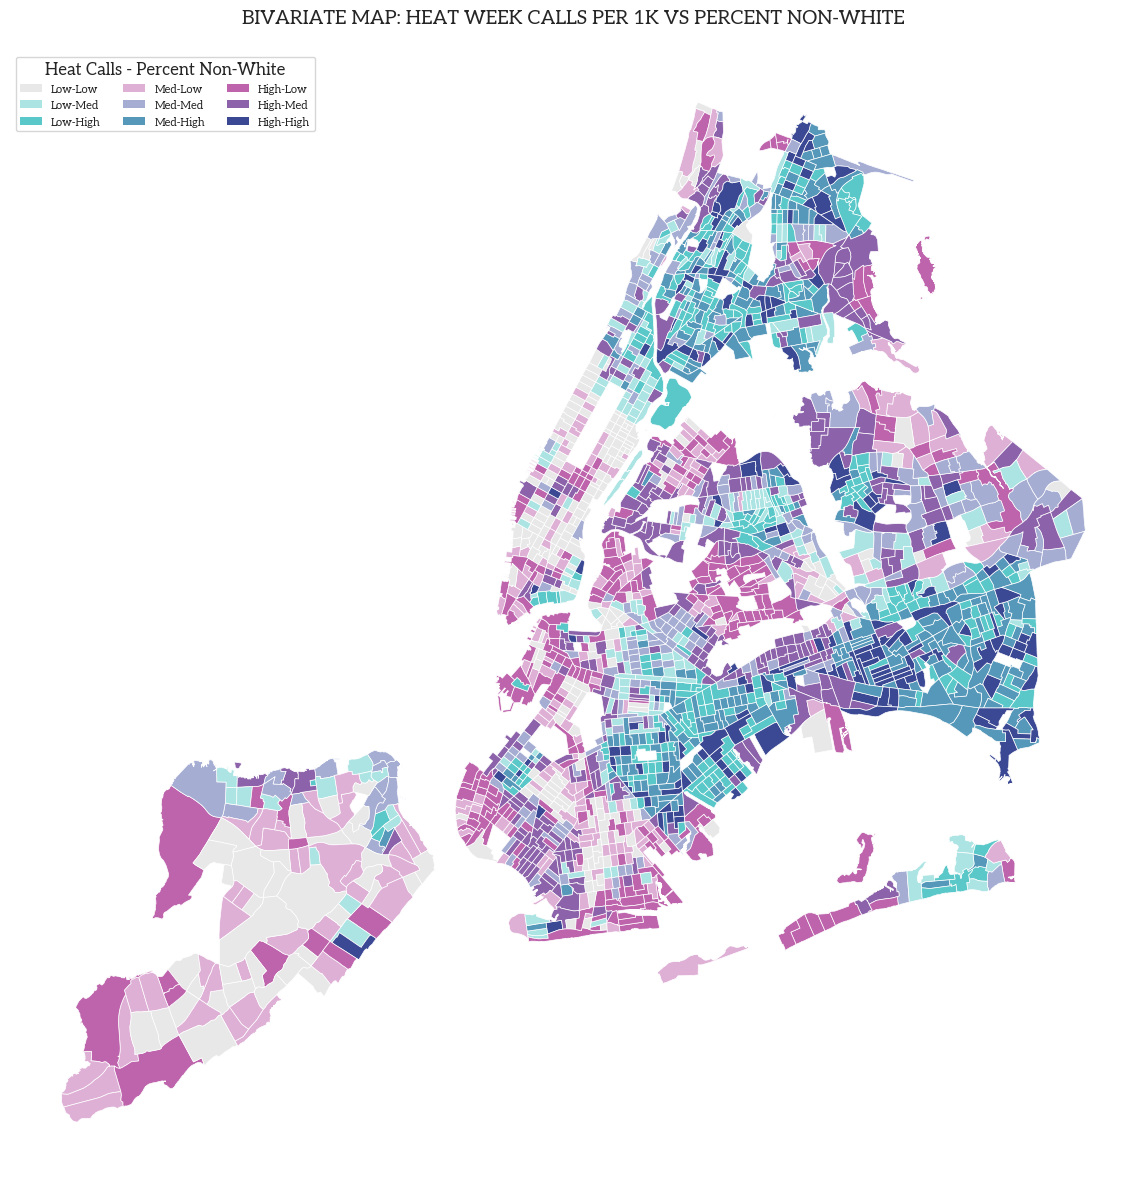

In [85]:
# Bivariate map: Heat week calls vs Tree canopy.
bivar_gdf1 = create_bivariate_map(
    gdf,
    "heatweek_calls_per_1k",
    "PCT_NON_WHITE",
    "BIVARIATE MAP: HEAT WEEK CALLS PER 1K VS PERCENT NON-WHITE\n",
    "Heat Calls",
    "Percent Non-White"
)

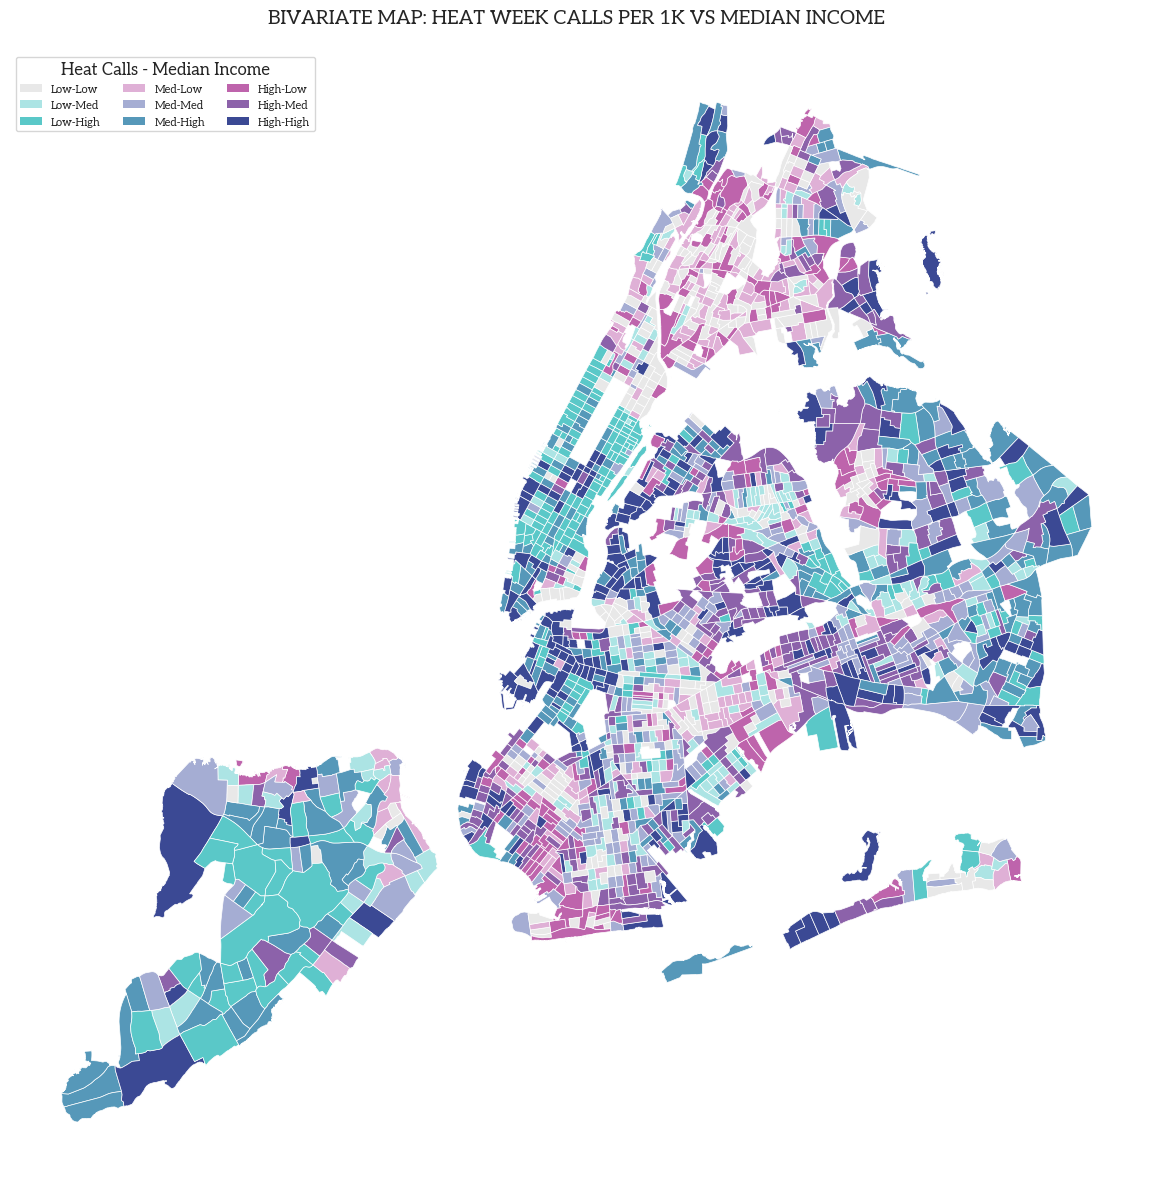

In [86]:
# Bivariate map: Heat week calls vs Median income.
# Filter out placeholder income values.
gdf_income = gdf.copy()
gdf_income.loc[gdf_income["MEDIAN_INCOME"] < 0, "MEDIAN_INCOME"] = np.nan

bivar_gdf2 = create_bivariate_map(
    gdf_income,
    "heatweek_calls_per_1k",
    "MEDIAN_INCOME",
    "BIVARIATE MAP: HEAT WEEK CALLS PER 1K VS MEDIAN INCOME\n",
    "Heat Calls",
    "Median Income"
)

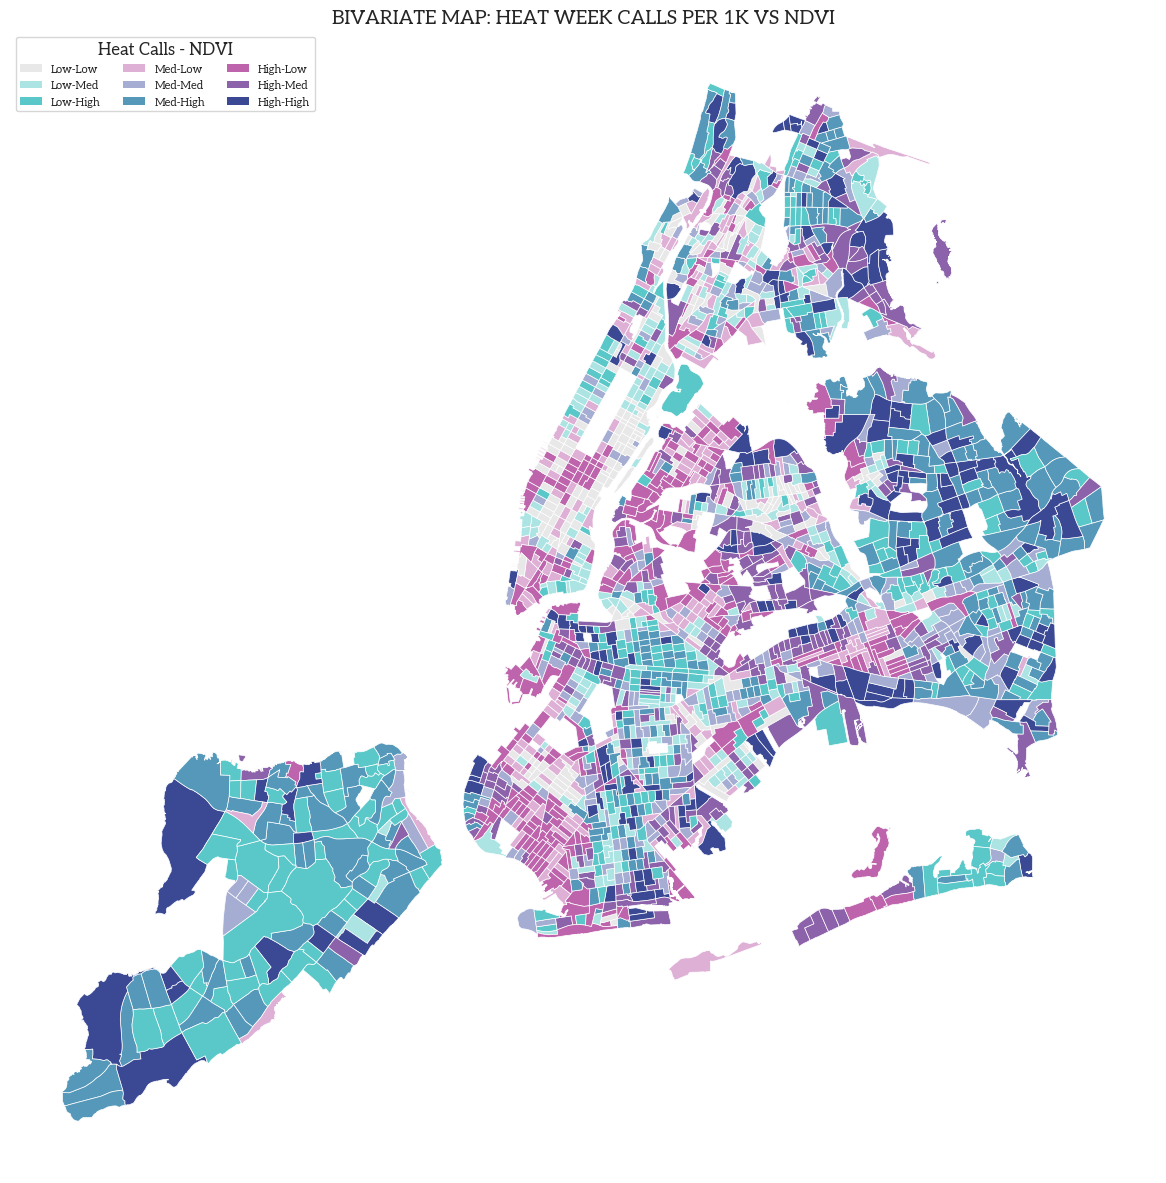

In [87]:
# Bivariate map: Heat week calls vs NDVI.
bivar_gdf3 = create_bivariate_map(
    gdf,
    "heatweek_calls_per_1k",
    "NDVI",
    "BIVARIATE MAP: HEAT WEEK CALLS PER 1K VS NDVI",
    "Heat Calls",
    "NDVI"
)

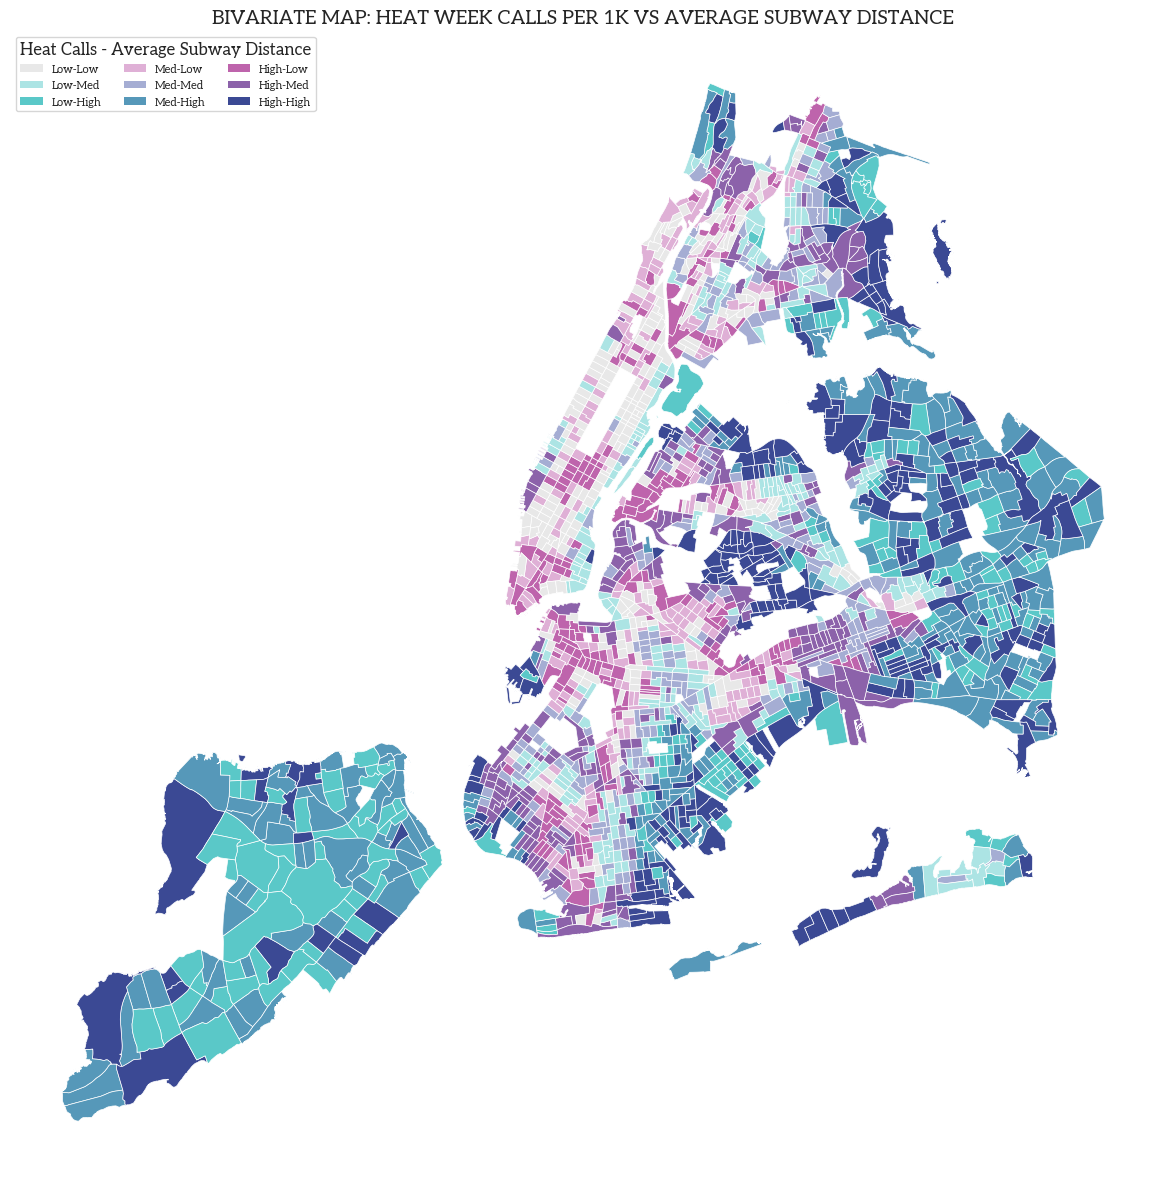

In [88]:
# Bivariate map: Heat week calls vs Subway distance.
bivar_gdf3 = create_bivariate_map(
    gdf,
    "heatweek_calls_per_1k",
    "KNN_SUBWAY_dist_mean",
    "BIVARIATE MAP: HEAT WEEK CALLS PER 1K VS AVERAGE SUBWAY DISTANCE",
    "Heat Calls",
    "Average Subway Distance"
)

## 7. Key Findings and Data Quality Notes

KEY EXPLORATORY DATA ANALYSIS FINDINGS

- TARGET VARIABLE CHARACTERISTICS:

   - Mean heat week calls per 1k: 1.794

   - Mean normal week calls per 1k: 1.892

   - Mean difference: -0.099 (-5.2% increase)

   - Tracts with increased calls during heat: 852 (38.3%)

- STRONGEST CORRELATIONS WITH HEAT WEEK CALLS:

   - MEDIAN_INCOME: -0.198

   - NDVI: -0.106

   - AH: 0.073

   - PCT_IMPERVIOUS: 0.068

   - PCT_NON_WHITE: -0.058

- MULTICOLLINEARITY CONCERNS:

   - 7 variable(s) with VIF > 10:

     • PCT_IMPERVIOUS: VIF = 53.83

     • BD: VIF = 24.34

     • PCT_BACHELORS_PLUS: VIF = 19.09

     • PCT_RENTERS: VIF = 18.63

     • MEDIAN_INCOME: VIF = 17.78

     • NDVI: VIF = 12.86

     • PCT_NON_WHITE: VIF = 10.02

- SPATIAL PATTERNS:

   - 6 variable(s) show significant spatial autocorrelation:

     • heatweek_calls_per_1k: Moran's I = 0.163 (p = 0.0010)

     • normalweek_calls_per_1k: Moran's I = 0.192 (p = 0.0010)

     • PCT_TREE_CANOPY: Moran's I = 0.640 (p = 0.0010)

     • PCT_IMPERVIOUS: Moran's I = 0.557 (p = 0.0010)

     • PCT_BACHELORS_PLUS: Moran's I = 0.792 (p = 0.0010)

     • PCT_RENTERS: Moran's I = 0.654 (p = 0.0010)

   - LISA Hot Spots (HH): 86 tracts

   - LISA Cold Spots (LL): 324 tracts

- DATA QUALITY NOTES:

   - Total census tracts: 2225

   - Complete cases (no missing in predictors): 2225

   - Missing data rate: 0.0%

   - MEDIAN_INCOME contains 25 placeholder values (coded as negative).